In [1]:
# Libraries
import caveclient
import subprocess
import json
import numpy as np
import matplotlib.pyplot as plt
# Setup caveclient
client = caveclient.CAVEclient("wclee_mouse_spinalcord_cltmr", ) #server_address='https://global.daf-apis.com')

In [2]:
# Synapses df
auto_tag = client.materialize.query_table('excitatory_neuron_label')
cell_tag = client.materialize.query_table('spinalcord_neuron_clusters_2')

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


In [3]:
set(cell_tag['tag'])

{'adltmr_module',
 'cltmr_module',
 'noci_module',
 'np_module',
 'p1',
 'p2_cold',
 'p2_noci',
 'p2_poly',
 'r',
 'v1',
 'v2'}

In [9]:
from collections import defaultdict
from tqdm import tqdm
import pandas as pd

# ---- config (adjust names here if needed) ----
V_AUTO_TABLE   = "synapses_version3"
MANUAL_TABLE   = "manual_synapses"   # <- use "manual_synapses" if that's the actual name
SIZE_THRESHOLD = 20                 # for v_auto only
POST_ONLY_TAGS = {"p1", "p2_cold", "p2_noci", "p2_poly"}

# ---- inputs assumed: cell_tag (pt_root_id, tag), auto_tag (pt_root_id + tag or cell_type='v_auto') ----
# normalize ID columns to string for consistent joins/comparisons
cell_tag = cell_tag.copy()
cell_tag["pt_root_id"] = cell_tag["pt_root_id"].astype(str)
if "pt_root_id" in auto_tag.columns:
    auto_tag = auto_tag.copy()
    auto_tag["pt_root_id"] = auto_tag["pt_root_id"].astype(str)

# map: pt_root_id -> set of tags (from cell_tag)
id_to_tags = (
    cell_tag.groupby("pt_root_id")["tag"]
    .apply(lambda s: set(s.dropna().astype(str)))
    .to_dict()
)

# build the set of v_auto root IDs from auto_tag
if "cell_type" in auto_tag.columns:
    v_auto_ids = set(auto_tag.loc[auto_tag["cell_type"] == "v_auto", "pt_root_id"].astype(str))
elif "tag" in auto_tag.columns:
    v_auto_ids = set(auto_tag.loc[auto_tag["tag"] == "v_auto", "pt_root_id"].astype(str))
else:
    # fallback: if auto_tag only lists IDs, treat all as v_auto
    v_auto_ids = set(auto_tag["pt_root_id"].astype(str))

# presynaptic candidates = all IDs in cell_tag minus those with any postsynaptic-only tag
all_ids = pd.Index(cell_tag["pt_root_id"].unique()).astype(str)
def is_presynaptic_allowed(root_id: str) -> bool:
    tags = id_to_tags.get(root_id, set())
    return tags.isdisjoint(POST_ONLY_TAGS)

presynaptic_ids = [rid for rid in all_ids if is_presynaptic_allowed(rid)]

# Build connectivity matrix
output_matrix = defaultdict(dict)

for pre_id in tqdm(presynaptic_ids, desc="Building connectivity (conditional tables)"):
    # choose table & filtering rule
    is_v_auto = pre_id in v_auto_ids
    table = V_AUTO_TABLE if is_v_auto else MANUAL_TABLE

    try:
        pre_syn_df = client.materialize.query_table(
            table,
            filter_equal_dict={"pre_pt_root_id": pre_id},
            #materialization_version=331
        )
    except Exception as e:
        print(f"⚠️ Failed to query neuron {pre_id} from {table}: {e}")
        continue

    if pre_syn_df is None or len(pre_syn_df) == 0:
        continue

    # common: exclude self-synapses
    filtered = pre_syn_df[pre_syn_df["pre_pt_root_id"].astype(str) != pre_syn_df["post_pt_root_id"].astype(str)]

    # extra size threshold for v_auto
    if is_v_auto and "size" in filtered.columns:
        filtered = filtered[filtered["size"] >= SIZE_THRESHOLD]

    if filtered.empty:
        continue

    # count postsynaptic targets
    syn_counts = filtered["post_pt_root_id"].astype(str).value_counts()

    # store
    for post_id, count in syn_counts.items():
        output_matrix[pre_id][post_id] = int(count)

# (optional) convert to an adjacency DataFrame
adjacency_df = (
    pd.DataFrame.from_dict(output_matrix, orient="index")
      .fillna(0)
      .astype(int)
      .sort_index(axis=0)
      .sort_index(axis=1)
)

# adjacency_df now has rows = presynaptic neurons (excluding p1/p2_* postsyn-only),
# columns = postsynaptic neurons encountered in queries (may include the p1/p2_* groups).


Building connectivity (conditional tables): 100%|██████████| 177/177 [02:11<00:00,  1.34it/s]


In [10]:
adjacency_df

,0,720575940379372135,720575940380629811,720575940382130353,720575940386337896,720575940386973320,720575940387023012,720575940387490662,720575940387532004,720575940388061875,...,720575940964211366,720575940964231590,720575940964240550,720575940964284070,720575940964298406,720575940964313510,720575940964347046,720575940964347302,720575940964357030,720575940964370854
720575940859648663,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
720575940861447666,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
720575940861450226,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
720575940865467295,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
720575940869443690,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720575940940380075,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
720575940941106028,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
720575940941124460,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
720575940946223236,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
# make sure IDs are strings (consistent with what we stored in output_matrix)
valid_posts = cell_tag["pt_root_id"].astype(str).unique()

# reindex columns so all valid posts are present, fill missing with 0
adjacency_df_restricted = (
    adjacency_df
    .reindex(columns=valid_posts, fill_value=0)
)

# (optional) sort rows and columns for consistency
adjacency_df_restricted = (
    adjacency_df_restricted
    .sort_index(axis=0)
    .sort_index(axis=1)
)


In [1]:
adjacency_df_restricted

NameError: name 'adjacency_df_restricted' is not defined

In [13]:
# expected posts = all cell_tag pt_root_id (as strings)
expected_posts = pd.Index(cell_tag["pt_root_id"].astype(str).unique())

# what we currently have
existing_posts = pd.Index(adjacency_df_restricted.columns.astype(str))

# which are missing?
missing_posts = expected_posts.difference(existing_posts)

print(f"Expected postsynaptic neurons: {len(expected_posts)}")
print(f"Existing columns: {len(existing_posts)}")
print(f"Missing postsynaptic columns to add: {len(missing_posts)}")

# add missing columns, filled with 0, and order columns to match expected list
adjacency_df_completed = adjacency_df_restricted.reindex(
    columns=expected_posts,  # ensures we have exactly this set, in this order
    fill_value=0
).astype(int)


Expected postsynaptic neurons: 223
Existing columns: 223
Missing postsynaptic columns to add: 0


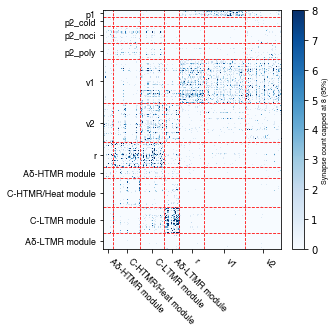

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- assumes you already have these defined ---
# adjacency_df_completed  # rows = presyn, cols = postsyn
# cell_tag                # columns: ['pt_root_id','tag']

# ------------------- configuration -------------------
# order of clusters (tags) on rows (posts) and columns (pres)
post_cluster_order = [
 "p1", "p2_cold", "p2_noci", "p2_poly", "v1", "v2", "r",
 "noci_module", "np_module","cltmr_module", "adltmr_module"
]
pre_cluster_order = [
 "noci_module", "np_module","cltmr_module", "adltmr_module",  "r", "v1", "v2"
]

# --- NEW: display remaps (applied to tick labels only) ---
POST_LABEL_MAP = {
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}
PRE_LABEL_MAP = {
    "islet-chtmr": "Islet CHTMR/Heat",
    "islet-cltmr": "Islet C-LTMR",
    "islet-adltmr": "Islet Aδ-LTMR",
    "IN for abltmr": "IhN Aβ-LTMR",
    "IN for adhtmr": "IhN Aδ-HTMR",
    "IN for vertical cell": "IhN Vertical",
    # also allow module names on the pres axis (if present)
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}

# ---- cap controls ----
CAP_MODE = "percentile"   # options: "none", "percentile"
CAP_PERCENTILE = 95       # used if CAP_MODE == "percentile"

# -----------------------------------------------------

# normalize ids/tags
ct = cell_tag.copy()
ct["pt_root_id"] = ct["pt_root_id"].astype(str)
ct["tag"] = ct["tag"].astype(str)

# primary tag per neuron (first occurrence)
first_tags = (
    ct.drop_duplicates(subset=["pt_root_id"], keep="first")
      .set_index("pt_root_id")["tag"]
)

# matrix with rows=posts, cols=pres
A = adjacency_df_completed.T.copy()

def ordered_categorical(series, order):
    s = series.fillna("unknown").astype(str)
    if order is None:
        cats = sorted(s.unique().tolist())
    else:
        cats, seen = [], set()
        for c in order:
            if c not in seen:
                cats.append(c); seen.add(c)
        for c in s.unique():
            if c not in seen:
                cats.append(c); seen.add(c)
    return pd.Categorical(s, categories=cats, ordered=True)

def compute_sorted_ids_and_bounds(ids, tag_map, cluster_order=None):
    ids = pd.Index(ids.astype(str))
    tags = tag_map.reindex(ids).fillna("unknown")
    cat = ordered_categorical(tags, cluster_order)
    order_df = pd.DataFrame({"id": ids, "tag": cat})
    order_df = order_df.sort_values(["tag","id"], kind="mergesort").reset_index(drop=True)
    sorted_ids = order_df["id"].tolist()

    starts, ends, labels = [], [], []
    for tag, grp in order_df.groupby("tag", sort=False, observed=True):
        starts.append(grp.index[0])
        ends.append(grp.index[-1] + 1)       # exclusive end
        labels.append(str(tag))

    centers = [ (s + e - 1) / 2.0 for s, e in zip(starts, ends) ]
    boundary_lines = [ e - 0.5 for e in ends[:-1] ]
    return sorted_ids, labels, centers, boundary_lines

# get row/col orders and boundaries
row_ids = A.index
col_ids = A.columns

row_sorted, row_labels, row_centers, row_boundaries = compute_sorted_ids_and_bounds(
    row_ids, first_tags, cluster_order=post_cluster_order
)
col_sorted, col_labels, col_centers, col_boundaries = compute_sorted_ids_and_bounds(
    col_ids, first_tags, cluster_order=pre_cluster_order
)

# reindex in the requested orders
A_sorted = A.reindex(index=row_sorted, columns=col_sorted, fill_value=0)

# ---- cap logic ----
vals = A_sorted.values
pos = vals[np.isfinite(vals) & (vals > 0)]

if CAP_MODE == "percentile":
    if pos.size > 0:
        vmax = float(np.percentile(pos, CAP_PERCENTILE))
        A_vis = A_sorted.clip(upper=vmax)
        cbar_note = f" (P{CAP_PERCENTILE} cap at {vmax:.3g})"
    else:
        vmax = 1.0
        A_vis = A_sorted
        cbar_note = " (no nonzero values)"
elif CAP_MODE == "none":
    vmax = None          # lets imshow autoscale the top
    A_vis = A_sorted     # no clipping
    cbar_note = " (uncapped)"
else:
    raise ValueError("CAP_MODE must be 'none' or 'percentile'.")

# ----------- plot -----------
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(
    A_vis.values,
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=vmax,            # None => uncapped autoscale
    interpolation="nearest"
)

# --- NEW: remap displayed tick labels only ---
row_labels_display = [POST_LABEL_MAP.get(lbl, lbl) for lbl in row_labels]
col_labels_display = [PRE_LABEL_MAP.get(lbl, lbl) for lbl in col_labels]

# cluster labels at centers (with remapped names)
ax.set_xticks(col_centers)
ax.set_xticklabels(col_labels_display, rotation=-45, ha="left", fontsize=9, fontname='Helvetica')
ax.set_yticks(row_centers)
ax.set_yticklabels(row_labels_display, fontsize=9, fontname='Helvetica')

# dashed red separators between clusters
for x in col_boundaries:
    ax.axvline(x, linestyle="--", color="red", linewidth=0.8)
for y in row_boundaries:
    ax.axhline(y, linestyle="--", color="red", linewidth=0.8)

# colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(f"Synapse count capped at 8 (95%)", fontsize=7, fontname='Helvetica')

cm = 1/2.54
fig = plt.gcf()
fig.set_size_inches(12*cm, 12*cm)     # 6 cm × 6 cm
plt.tight_layout()
#plt.savefig("interneuron_matrix_figure4/connectivity_011526.png", dpi=600, bbox_inches="tight")
plt.show()



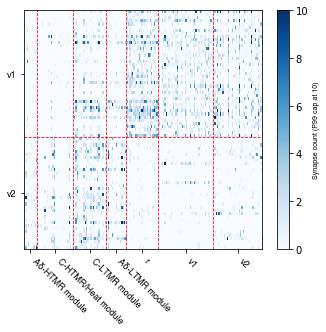

In [15]:
# vertical cells only (postsyn = v1/v2), same presyn set as before
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------- configuration -------------------
v_post_cluster_order = ["v1", "v2"]

v_pre_cluster_order = [
    "noci_module",
    "np_module",
    "cltmr_module",
    "adltmr_module",
    "r",
    "v1",
    "v2",
]

POST_LABEL_MAP = {
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}

PRE_LABEL_MAP = {
    "islet-chtmr": "Islet CHTMR/Heat",
    "islet-cltmr": "Islet C-LTMR",
    "islet-adltmr": "Islet Aδ-LTMR",
    "IN for abltmr": "IhN Aβ-LTMR",
    "IN for adhtmr": "IhN Aδ-HTMR",
    "IN for vertical cell": "IhN Vertical",
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}

CAP_MODE = "percentile"
CAP_PERCENTILE = 99

# -----------------------------------------------------

ct = cell_tag.copy()
ct["pt_root_id"] = ct["pt_root_id"].astype(str)
ct["tag"] = ct["tag"].astype(str)

first_tags = (
    ct.drop_duplicates(subset=["pt_root_id"], keep="first")
      .set_index("pt_root_id")["tag"]
)

# adjacency_df_completed: rows=pres, cols=posts
# A: rows=posts, cols=pres
A = adjacency_df_completed.T.copy()
A.index = A.index.astype(str)
A.columns = A.columns.astype(str)

def ordered_categorical(series, order):
    s = series.fillna("unknown").astype(str)

    if order is None:
        cats = sorted(s.unique().tolist())
    else:
        cats, seen = [], set()
        for c in order:
            if c not in seen:
                cats.append(c)
                seen.add(c)
        for c in s.unique():
            if c not in seen:
                cats.append(c)
                seen.add(c)

    return pd.Categorical(s, categories=cats, ordered=True)


def compute_sorted_ids_and_bounds(ids, tag_map, cluster_order=None):
    ids = pd.Index(pd.Index(ids).astype(str))
    tags = tag_map.reindex(ids).fillna("unknown")
    cat = ordered_categorical(tags, cluster_order)

    order_df = pd.DataFrame({"id": ids, "tag": cat})
    order_df = order_df.sort_values(["tag", "id"], kind="mergesort").reset_index(drop=True)

    sorted_ids = order_df["id"].tolist()

    starts, ends, labels = [], [], []

    for tag, grp in order_df.groupby("tag", sort=False, observed=True):
        starts.append(grp.index[0])
        ends.append(grp.index[-1] + 1)
        labels.append(str(tag))

    centers = [(s + e - 1) / 2.0 for s, e in zip(starts, ends)]
    boundary_lines = [e - 0.5 for e in ends[:-1]]

    return sorted_ids, labels, centers, boundary_lines


# -----------------------------------------------------
# Filter to ONLY v1/v2 postsynaptic neurons
# -----------------------------------------------------

v_row_ids_all = A.index.astype(str)
v_row_tags_all = first_tags.reindex(v_row_ids_all).fillna("unknown").astype(str)
v_row_keep = v_row_tags_all.isin(v_post_cluster_order)
v_row_ids = v_row_ids_all[v_row_keep]

v_col_ids = A.columns.astype(str)

# IMPORTANT: use v_ variable names so you do NOT overwrite
# row_sorted, col_sorted, row_labels, etc. from your full plot.
v_row_sorted, v_row_labels, v_row_centers, v_row_boundaries = compute_sorted_ids_and_bounds(
    v_row_ids,
    first_tags,
    cluster_order=v_post_cluster_order,
)

v_col_sorted, v_col_labels, v_col_centers, v_col_boundaries = compute_sorted_ids_and_bounds(
    v_col_ids,
    first_tags,
    cluster_order=v_pre_cluster_order,
)

A_sorted = A.reindex(
    index=v_row_sorted,
    columns=v_col_sorted,
    fill_value=0,
)

# ---- cap logic ----
vals = A_sorted.values
pos = vals[np.isfinite(vals) & (vals > 0)]

if CAP_MODE == "percentile":
    if pos.size > 0:
        vmax = float(np.percentile(pos, CAP_PERCENTILE))
        A_vis = A_sorted.clip(upper=vmax)
        cbar_note = f" (P{CAP_PERCENTILE} cap at {vmax:.3g})"
    else:
        vmax = 1.0
        A_vis = A_sorted
        cbar_note = " (no nonzero values)"

elif CAP_MODE == "none":
    vmax = None
    A_vis = A_sorted
    cbar_note = " (uncapped)"

else:
    raise ValueError("CAP_MODE must be 'none' or 'percentile'.")


# ----------- plot -----------
fig, ax = plt.subplots(figsize=(11, 9))

im = ax.imshow(
    A_vis.values,
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=vmax,
    interpolation="nearest",
)

v_row_labels_display = [POST_LABEL_MAP.get(lbl, lbl) for lbl in v_row_labels]
v_col_labels_display = [PRE_LABEL_MAP.get(lbl, lbl) for lbl in v_col_labels]

ax.set_xticks(v_col_centers)
ax.set_xticklabels(
    v_col_labels_display,
    rotation=-45,
    ha="left",
    fontsize=9,
    fontname="Helvetica",
)

ax.set_yticks(v_row_centers)
ax.set_yticklabels(
    v_row_labels_display,
    fontsize=9,
    fontname="Helvetica",
)

for x in v_col_boundaries:
    ax.axvline(x, linestyle="--", color="red", linewidth=0.8)

for y in v_row_boundaries:
    ax.axhline(y, linestyle="--", color="red", linewidth=0.8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    f"Synapse count{cbar_note}",
    fontsize=7,
    fontname="Helvetica",
)

cm = 1 / 2.54
fig.set_size_inches(12 * cm, 12 * cm)

plt.tight_layout()
# plt.savefig("interneuron_matrix_figure4/vertical_connectivity_011426.png", dpi=600, bbox_inches="tight")
plt.show()

In [16]:
adjacency_df_restricted

,720575940859648663,720575940861447666,720575940861450226,720575940865160474,720575940865467295,720575940869443690,720575940869481691,720575940871589433,720575940875116119,720575940875854397,...,720575940937862061,720575940937894317,720575940939715909,720575940940380075,720575940941106028,720575940941124460,720575940946223236,720575940948987670,720575940963340820,720575940964370854
720575940859648663,0,0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,2
720575940861447666,4,0,0,0,0,0,0,0,0,0,...,0,3,0,0,0,0,0,0,0,0
720575940861450226,0,4,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
720575940865467295,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
720575940869443690,0,0,0,0,0,0,3,0,3,0,...,0,0,0,3,2,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720575940940380075,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,2,0,0,0
720575940941106028,0,0,0,0,0,0,0,0,0,0,...,0,0,10,0,0,0,0,0,0,0
720575940941124460,0,0,0,0,0,0,0,0,0,0,...,0,0,0,10,0,0,0,2,0,0
720575940946223236,1,0,0,0,0,0,0,0,0,1,...,0,3,0,0,0,0,0,0,0,0


In [17]:
import pandas as pd

# Path to your file
csv_path = "/Users/wangchu/connectivity_analysis/interneuron_matrix_figure4/neuron_pairs_with_axon_length.csv"

# Load CSV
df = pd.read_csv(csv_path)

# Convert axon length to microns
df["axon_length_um"] = df["axon_length"] / 1000.0

# Build adjacency matrix
overlap_df = df.pivot_table(
    index="root_id_1",
    columns="root_id_2",
    values="axon_length_um",
    aggfunc="sum",
    fill_value=0.0
)

# Drop axis names so rows/cols are just root_ids
overlap_df.index.name = None
overlap_df.columns.name = None

# Save
#overlap_df.to_csv("/Users/wangchu/connectivity_analysis/interneuron_matrix_figure4/axon_dend_overlap_adjacency.csv")

print("overlap_df shape:", overlap_df.shape)
#print(overlap_df.head())


overlap_df shape: (177, 223)


In [18]:
overlap_df

,720575940859648663,720575940861447666,720575940865160474,720575940865467295,720575940869443690,720575940870686550,720575940875116119,720575940875854397,720575940875863357,720575940877146203,...,720575940937857965,720575940937862061,720575940939715909,720575940940380075,720575940940386475,720575940941106028,720575940941124460,720575940946223236,720575940948987670,720575940963340820
720575940859648663,28.503471,0.000000,6.401048,43.807018,57.000419,0.000000,0.000000,169.474360,23.955922,28.892016,...,84.311751,0.000000,12.889577,62.109168,102.052704,186.266584,0.000000,121.227251,0.000000,51.931573
720575940861447666,71.340946,89.408269,3.861357,0.000000,7.600695,275.974682,7.142930,36.273838,0.000000,7.367208,...,25.625357,0.000000,112.453013,0.000000,9.520194,0.000000,0.000000,16.449623,14.099883,0.000000
720575940865467295,36.913636,0.000000,0.000000,44.507326,0.000000,0.000000,0.000000,0.000000,0.000000,14.169004,...,0.000000,0.000000,0.000000,0.000000,50.532247,0.000000,0.000000,0.000000,0.000000,19.381092
720575940869443690,29.316247,26.213108,9.197210,0.000000,371.222721,42.661318,403.657003,95.584847,0.000000,0.000000,...,97.057084,17.548886,45.132117,78.200960,7.606958,108.845737,85.544922,22.067576,44.696281,21.496237
720575940870686550,0.000000,209.206212,0.000000,0.000000,195.857271,479.226453,4.705643,12.461251,0.000000,0.000000,...,10.734175,20.945795,15.590156,0.000000,8.437171,4.235665,81.453602,0.000000,7.946952,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720575940940380075,114.668515,15.723216,11.287978,10.350635,79.286491,5.732786,31.768496,55.200810,0.000000,35.065716,...,0.000000,181.410738,78.124923,152.766439,66.718942,26.481462,29.980197,267.002497,150.964730,25.368144
720575940941106028,119.651830,48.985077,0.000000,16.123500,32.415458,18.652529,99.128672,113.125444,0.000000,119.039320,...,424.431755,0.000000,195.047555,180.443212,39.820938,1053.627771,0.000000,165.721408,0.000000,112.805379
720575940941124460,257.592421,17.679871,0.000000,0.000000,1430.881536,67.711196,82.076366,365.547598,0.000000,47.882607,...,263.373287,1330.084114,13.190922,1247.376669,0.000000,23.730103,200.571855,474.874499,791.804104,13.435357
720575940946223236,141.975582,0.000000,0.000000,7.535255,147.088737,0.000000,71.307434,156.334424,0.000000,0.000000,...,80.636888,70.721818,0.000000,199.570118,2.759672,57.056253,50.179572,251.983998,0.000000,0.000000


In [19]:
import pandas as pd

def normalize_id_index(idx_like):
    s = pd.Index(idx_like).astype(str).str.strip()

    def to_canonical(x):
        try:
            val = pd.to_numeric(x, errors="raise")
            if pd.notna(val) and float(val).is_integer():
                return str(int(val))
        except Exception:
            pass
        return x

    return pd.Index(s.map(to_canonical), name=None)


def rename_ids_matrix(df, mapping):
    """
    Rename row/column IDs using mapping.
    Duplicate rows/columns created by remapping are merged by summing.
    """
    out = df.copy()

    out.index = normalize_id_index(out.index).to_series().replace(mapping).values
    out.columns = normalize_id_index(out.columns).to_series().replace(mapping).values

    out = out.apply(pd.to_numeric, errors="coerce").fillna(0)

    if out.index.duplicated().any():
        out = out.groupby(level=0).sum()

    if out.columns.duplicated().any():
        out = out.T.groupby(level=0).sum().T

    return out


def build_adjacency_validated_remap(overlap_df, adjacency_df_restricted, client):
    """
    Build old -> latest root remap for IDs in overlap_df.

    Critical rule:
    A remapped ID is accepted ONLY if it appears in adjacency_df_restricted.

    Handles:
    - one latest root
    - split into multiple latest roots
    - unresolved cases
    """

    overlap_df = overlap_df.copy()
    adjacency_df_restricted = adjacency_df_restricted.copy()

    overlap_df.index = normalize_id_index(overlap_df.index)
    overlap_df.columns = normalize_id_index(overlap_df.columns)

    adjacency_df_restricted.index = normalize_id_index(adjacency_df_restricted.index)
    adjacency_df_restricted.columns = normalize_id_index(adjacency_df_restricted.columns)

    overlap_ids = set(overlap_df.index) | set(overlap_df.columns)
    adjacency_ids = set(adjacency_df_restricted.index) | set(adjacency_df_restricted.columns)

    candidate_old_ids = sorted(overlap_ids - adjacency_ids)

    print("# candidate outdated IDs in overlap_df:", len(candidate_old_ids))

    id_remap = {}
    unresolved = {}

    for old_id in candidate_old_ids:
        latest_roots = client.chunkedgraph.get_latest_roots(int(old_id))
        latest_roots = [str(int(x)) for x in latest_roots]

        latest_roots_in_adjacency = [
            rid for rid in latest_roots
            if rid in adjacency_ids
        ]

        if len(latest_roots_in_adjacency) == 1:
            id_remap[old_id] = latest_roots_in_adjacency[0]

        else:
            unresolved[old_id] = {
                "latest_roots": latest_roots,
                "latest_roots_in_adjacency": latest_roots_in_adjacency,
            }

    return id_remap, unresolved

In [20]:
ID_REMAP, unresolved = build_adjacency_validated_remap(
    overlap_df,
    adjacency_df_restricted,
    client
)

print("\nID_REMAP:")
for old_id, new_id in ID_REMAP.items():
    print(f"{old_id} -> {new_id}")

print("\nUnresolved cases:")
for old_id, info in unresolved.items():
    print(old_id, info)

overlap_df = rename_ids_matrix(overlap_df, ID_REMAP)

# candidate outdated IDs in overlap_df: 26

ID_REMAP:
720575940870686550 -> 720575940861450226
720575940881055666 -> 720575940921583379
720575940881607875 -> 720575940869481691
720575940881935185 -> 720575940888845329
720575940881935355 -> 720575940883803384
720575940881936465 -> 720575940926242958
720575940882117920 -> 720575940920080765
720575940882160356 -> 720575940896304311
720575940882393805 -> 720575940892250110
720575940883901724 -> 720575940878978356
720575940886540578 -> 720575940898916857
720575940887194266 -> 720575940889967848
720575940888793178 -> 720575940871589433
720575940888802138 -> 720575940964370854
720575940889249143 -> 720575940919071815
720575940891183798 -> 720575940906210525
720575940906113851 -> 720575940893177002
720575940910607129 -> 720575940889813349
720575940917531755 -> 720575940937894317
720575940917780131 -> 720575940922814762
720575940920044149 -> 720575940920932008
720575940924431938 -> 720575940886290596
720575940928355836 -> 720575940893329739
720

In [21]:
overlap_ids = set(overlap_df.index.astype(str)) | set(overlap_df.columns.astype(str))
adjacency_ids = set(adjacency_df_restricted.index.astype(str)) | set(adjacency_df_restricted.columns.astype(str))

print("\nAfter remapping:")
print("# only in overlap_df:", len(overlap_ids - adjacency_ids))
print("# only in adjacency_df_restricted:", len(adjacency_ids - overlap_ids))

print("only in overlap_df:", sorted(overlap_ids - adjacency_ids))
print("only in adjacency_df_restricted:", sorted(adjacency_ids - overlap_ids))


After remapping:
# only in overlap_df: 0
# only in adjacency_df_restricted: 0
only in overlap_df: []
only in adjacency_df_restricted: []


import pandas as pd

# old → new IDs (as strings)
ID_REMAP = {
    "720575940883901724": "720575940888806490",
    "720575940870686550": "720575940861450226",
    "720575940906113851": "720575940893177002",
    "720575940881607875": "720575940869481691",
    "720575940917780131": "720575940922814762",
    "720575940888806490": "720575940878978356",
    "720575940881936465": "720575940926242958",
    "720575940881055666": "720575940921583379",
    "720575940882117920": "720575940920080765",
    "720575940882160356": "720575940896304311",
    "720575940887194266": "720575940889967848",
    "720575940888802138": "720575940964370854",
    "720575940888806490": "720575940878978356",
    "720575940889249143": "720575940919071815",
    "720575940917531755": "720575940937894317",
    "720575940928355836": "720575940893329739",
    "720575940937221662": "720575940909430811",
    "720575940882393805": "720575940892250110",
    "720575940924431938": "720575940886290596",
    "720575940940386475": "720575940888561868"
    
}

def rename_ids_matrix(df: pd.DataFrame, mapping: dict) -> pd.DataFrame:
    """Rename row/column IDs using `mapping` on both axes.
    If renaming creates duplicate rows/cols, merge them by summing.
    """
    out = df.copy()
    out.index = out.index.astype(str).to_series().replace(mapping).values
    out.columns = out.columns.astype(str).to_series().replace(mapping).values

    # ensure numeric for safe summation
    out = out.apply(pd.to_numeric, errors="coerce").fillna(0)

    # merge duplicate rows
    if out.index.duplicated().any():
        out = out.groupby(level=0).sum()

    # merge duplicate columns
    if out.columns.duplicated().any():
        out = out.T.groupby(level=0).sum().T

    return out

# ---- apply to your overlap_df ----
overlap_df = rename_ids_matrix(overlap_df, ID_REMAP)

# (optional) keep appended version in sync too:
# app_overlap_df = rename_ids_matrix(app_overlap_df, ID_REMAP)

# (optional) if you maintain pre/post maps keyed by IDs, update their indices as well:
def rename_ids_series(s: pd.Series, mapping: dict) -> pd.Series:
    ss = s.copy()
    ss.index = ss.index.astype(str).to_series().replace(mapping).values
    # if duplicates arise, keep the first (labels should match anyway)
    if ss.index.duplicated().any():
        ss = ss[~ss.index.duplicated(keep="first")]
    return ss

# Example (uncomment if needed):
# app_pre_map = rename_ids_series(app_pre_map, ID_REMAP)
# post_map    = rename_ids_series(post_map, ID_REMAP)


import pandas as pd
import re

def normalize_id_index(idx_like):
    """
    Return a pandas.Index of canonical string IDs:
    - strip whitespace
    - convert floats like '7.205759408911819e17' or '7205... .0' to integer strings
    - leave non-numeric IDs as their stripped string
    """
    s = pd.Index(idx_like)

    # Convert to string first
    s_str = s.astype(str).str.strip()

    # Try to coerce numeric-looking strings safely to integers
    def to_canonical(x):
        xs = x.strip()
        # quick path: only digits
        if xs.isdigit():
            return xs
        # numeric-like? try to parse
        try:
            # handle scientific notation or trailing .0
            val = pd.to_numeric(xs, errors='raise')
            # only cast to int if it truly represents an integer
            if pd.notna(val) and float(val).is_integer():
                return str(int(val))
            else:
                # e.g., '123.45' — uncommon for root IDs; keep original
                return xs
        except Exception:
            # not numeric; keep as-is
            return xs

    canon = s_str.map(to_canonical)
    return pd.Index(canon, name=None)

# --- 1) Canonicalize IDs on both dataframes ---
overlap_df = overlap_df.copy()
adjacency_df_restricted = adjacency_df_restricted.copy()

overlap_df.index  = normalize_id_index(overlap_df.index)
overlap_df.columns = normalize_id_index(overlap_df.columns)

adjacency_df_restricted.index  = normalize_id_index(adjacency_df_restricted.index)
adjacency_df_restricted.columns = normalize_id_index(adjacency_df_restricted.columns)

# --- 2) Compare sets (rows & cols) ---
rows_overlap = set(overlap_df.index)
rows_restrict = set(adjacency_df_restricted.index)
cols_overlap = set(overlap_df.columns)
cols_restrict = set(adjacency_df_restricted.columns)

print("Row sets identical? ", rows_overlap == rows_restrict)
print("  #only in overlap_df rows:", len(rows_overlap - rows_restrict))
print("  #only in adjacency_df_restricted rows:", len(rows_restrict - rows_overlap))

print("\nColumn sets identical? ", cols_overlap == cols_restrict)
print("  #only in overlap_df cols:", len(cols_overlap - cols_restrict))
print("  #only in adjacency_df_restricted cols:", len(cols_restrict - cols_overlap))

# (optional) peek at a few differences
if rows_overlap != rows_restrict:
    print("\nSample rows only in overlap_df:", list(rows_overlap - rows_restrict)[:30])
    print("Sample rows only in adjacency_df_restricted:", list(rows_restrict - rows_overlap)[:30])

if cols_overlap != cols_restrict:
    print("\nSample cols only in overlap_df:", list(cols_overlap - cols_restrict)[:30])
    print("Sample cols only in adjacency_df_restricted:", list(cols_restrict - cols_overlap)[:30])

# --- 3) If you want overlap_df aligned to adjacency_df_restricted’s order ---
# Missing entries will be NaN; fill with 0 if that makes sense for you.
overlap_df_aligned = overlap_df.reindex(
    index=adjacency_df_restricted.index,
    columns=adjacency_df_restricted.columns
).fillna(0.0)

print("\nAligned overlap_df shape:", overlap_df_aligned.shape)



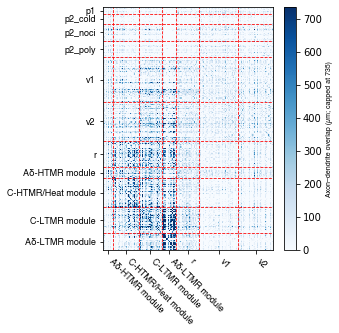

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# --- display remaps (labels only; data & ordering unchanged) ---
POST_LABEL_MAP = {
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}
PRE_LABEL_MAP = {
    "islet-chtmr": "Islet CHTMR/Heat",
    "islet-cltmr": "Islet C-LTMR",
    "islet-adltmr": "Islet Aδ-LTMR",
    "IN for abltmr": "IhN Aβ-LTMR",
    "IN for adhtmr": "IhN Aδ-HTMR",
    "IN for vertical cell": "IhN Vertical",
    # allow module names on x-axis too (if present)
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}

# ---- Plot overlap_df in the SAME neuron order as your adjacency plot ----
O = overlap_df.copy()
O.index = O.index.astype(str)
O.columns = O.columns.astype(str)

# rows = posts, cols = pres (match your adjacency plot convention)
O = O.T

# Align to exact order you already computed for adjacency
O_sorted = O.reindex(index=row_sorted, columns=col_sorted, fill_value=0.0)

# 99th percentile cap for contrast
if np.nanmax(O_sorted.values) > 0:
    vmax_overlap = float(np.nanpercentile(O_sorted.values, 99))
    if vmax_overlap <= 0:
        vmax_overlap = float(np.nanmax(O_sorted.values))
else:
    vmax_overlap = 1.0

O_vis = O_sorted.clip(upper=vmax_overlap)

# ---- plot ----
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(
    O_vis.values, aspect="auto", cmap="Blues",
    vmin=0, vmax=vmax_overlap, interpolation="nearest"
)

# --- remap tick labels ONLY (reuse centers/boundaries from adjacency) ---
row_labels_display = [POST_LABEL_MAP.get(lbl, lbl) for lbl in row_labels]
col_labels_display = [PRE_LABEL_MAP.get(lbl, lbl) for lbl in col_labels]

ax.set_xticks(col_centers)
ax.set_xticklabels(col_labels_display, rotation=-45, ha="left", fontsize=9, fontname='Helvetica')
ax.set_yticks(row_centers)
ax.set_yticklabels(row_labels_display, fontsize=9, fontname='Helvetica')

for x in col_boundaries:
    ax.axvline(x, linestyle="--", color="red", linewidth=0.8)
for y in row_boundaries:
    ax.axhline(y, linestyle="--", color="red", linewidth=0.8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(f"Axon–dendrite overlap (µm; capped at {vmax_overlap:.0f})", fontsize=7, fontname='Helvetica')

cm = 1/2.54
fig.set_size_inches(12*cm, 12*cm)  # 6 cm × 6 cm
plt.tight_layout()
#plt.savefig("interneuron_matrix_figure4/overlap_matrix_011326.png", dpi=600, bbox_inches="tight")
plt.show()


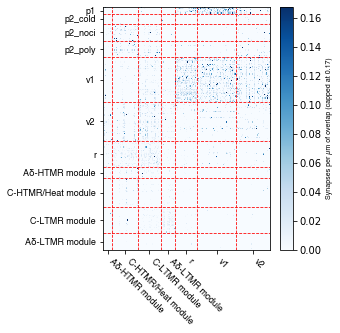

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- display remaps (labels only; data & ordering unchanged) ---
POST_LABEL_MAP = {
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}
PRE_LABEL_MAP = {
    "islet-chtmr": "Islet CHTMR/Heat",
    "islet-cltmr": "Islet C-LTMR",
    "islet-adltmr": "Islet Aδ-LTMR",
    "IN for abltmr": "IhN Aβ-LTMR",
    "IN for adhtmr": "IhN Aδ-HTMR",
    "IN for vertical cell": "IhN Vertical",
    # allow module names on x-axis too (if present)
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}

# --- Ensure matching dtypes and orientation (rows=posts, cols=pres) ---
A = adjacency_df_completed.copy()
O = overlap_df.copy()

A.index = A.index.astype(str); A.columns = A.columns.astype(str)
O.index = O.index.astype(str); O.columns = O.columns.astype(str)

A = A.T  # posts x pres
O = O.T  # posts x pres (µm of overlap)

# --- Align to the exact neuron order you already computed ---
A_sorted = A.reindex(index=row_sorted, columns=col_sorted, fill_value=0).astype(float)
O_sorted = O.reindex(index=row_sorted, columns=col_sorted, fill_value=0.0).astype(float)

# --- Normalize: synapses per µm of overlap ---
density_vals = np.divide(
    A_sorted.values,
    O_sorted.values,
    out=np.zeros_like(A_sorted.values, dtype=float),
    where=(O_sorted.values > 0)
)
density_df = pd.DataFrame(density_vals, index=row_sorted, columns=col_sorted)

# (Optional) if you prefer synapses per mm instead of per µm:
# density_df = density_df * 1000.0
# density_unit = "Synapses per mm of overlap"
density_unit = "Synapses per µm of overlap"

# --- Choose visualization cap for contrast (99th percentile of positive entries) ---
pos = density_df.values[np.isfinite(density_df.values) & (density_df.values > 0)]
vmax_density = float(np.percentile(pos, 99)) if pos.size > 0 else 1.0
if vmax_density <= 0:
    vmax_density = 1.0
D_vis = density_df.clip(upper=vmax_density)

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(D_vis.values, aspect="auto", cmap="Blues", vmin=0, vmax=vmax_density, interpolation="nearest")

# --- remap tick labels ONLY (reuse centers/boundaries you already have) ---
row_labels_display = [POST_LABEL_MAP.get(lbl, lbl) for lbl in row_labels]
col_labels_display = [PRE_LABEL_MAP.get(lbl,  lbl) for lbl in col_labels]

ax.set_xticks(col_centers)
ax.set_xticklabels(col_labels_display, rotation=-45, ha="left", fontsize=9, fontname='Helvetica')
ax.set_yticks(row_centers)
ax.set_yticklabels(row_labels_display, fontsize=9, fontname='Helvetica')

for x in col_boundaries:
    ax.axvline(x, linestyle="--", color="red", linewidth=0.8)
for y in row_boundaries:
    ax.axhline(y, linestyle="--", color="red", linewidth=0.8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(f"{density_unit} (capped at {vmax_density:.2g})", fontsize=7, fontname='Helvetica')

cm = 1/2.54
fig.set_size_inches(12*cm, 12*cm)  # 6 cm × 6 cm
plt.tight_layout()
#plt.savefig("interneuron_matrix_figure4/density_matrix_6cm_011326.png", dpi=600, bbox_inches="tight")
plt.show()



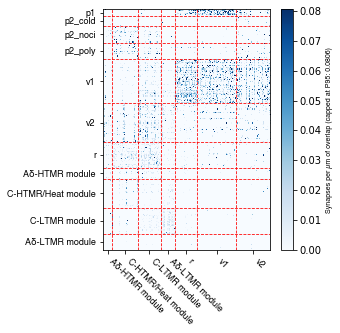

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# --- display remaps (labels only) ---
POST_LABEL_MAP = {
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}
PRE_LABEL_MAP = {
    "islet-chtmr": "Islet CHTMR/Heat",
    "islet-cltmr": "Islet C-LTMR",
    "islet-adltmr": "Islet Aδ-LTMR",
    "IN for abltmr": "IhN Aβ-LTMR",
    "IN for adhtmr": "IhN Aδ-HTMR",
    "IN for vertical cell": "IhN Vertical",
    # allow module names on x-axis too (if present)
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}

# --- Cap controls ---
CAP_MODE    = "percentile"   # options: "percentile", "fixed", "none"
PERCENTILE  = 95             # used if CAP_MODE == "percentile"
FIXED_VMAX  = 0.02           # used if CAP_MODE == "fixed" (e.g., synapses per µm)

# Compute vmax and matrix to plot
vals = density_df.values
pos  = vals[np.isfinite(vals) & (vals > 0)]

if CAP_MODE == "percentile":
    vmax = float(np.percentile(pos, PERCENTILE)) if pos.size > 0 else None
    matrix_to_plot = density_df if vmax is None else density_df.clip(upper=vmax)
    cbar_note = "" if vmax is None else f" (capped at P{PERCENTILE}: {vmax:.3g})"

elif CAP_MODE == "fixed":
    vmax = float(FIXED_VMAX)
    matrix_to_plot = density_df.clip(upper=vmax)
    cbar_note = f" (capped at {vmax:.3g})"

elif CAP_MODE == "none":
    vmax = None
    matrix_to_plot = density_df
    cbar_note = " (uncapped)"

else:
    raise ValueError("CAP_MODE must be 'percentile', 'fixed', or 'none'.")

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(
    matrix_to_plot.values,
    aspect="auto",
    cmap="Blues",
    vmin=0,          # keep bottom anchored at 0
    vmax=vmax,       # None => uncapped autoscale
    interpolation="nearest"
)

# --- remap tick labels ONLY (reuse centers/boundaries you already computed) ---
row_labels_display = [POST_LABEL_MAP.get(lbl, lbl) for lbl in row_labels]
col_labels_display = [PRE_LABEL_MAP.get(lbl,  lbl) for lbl in col_labels]

ax.set_xticks(col_centers)
ax.set_xticklabels(col_labels_display, rotation=-45, ha="left", fontsize=9, fontname='Helvetica')
ax.set_yticks(row_centers)
ax.set_yticklabels(row_labels_display, fontsize=9, fontname='Helvetica')

for x in col_boundaries:
    ax.axvline(x, linestyle="--", color="red", linewidth=0.8)
for y in row_boundaries:
    ax.axhline(y, linestyle="--", color="red", linewidth=0.8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(f"{density_unit}{cbar_note}", fontsize=7, fontname='Helvetica')

cm = 1/2.54
fig.set_size_inches(12*cm, 12*cm)
plt.tight_layout()
#plt.savefig("interneuron_matrix_figure4/density_matrix_6cm_capped_011326.png", dpi=600, bbox_inches="tight")
plt.show()


# -------- Safe display fallback (Option B) --------
from typing import Optional
import pandas as pd
from IPython.display import display

# Try to use Styler; if it fails (old jinja2), fall back gracefully.
try:
    from pandas.io.formats.style import Styler  # noqa: F401
    _HAS_STYLER = True
except Exception:
    _HAS_STYLER = False

def safe_display_table(df: pd.DataFrame, fmt: Optional[str], caption: str) -> None:
    """
    Display df using Styler if available; otherwise fall back to a simple display.
    fmt examples: '{:.0f}', '{:.3f}', '{:.2%}', or None.
    """
    if _HAS_STYLER:
        sty = df.style
        if fmt is not None:
            sty = sty.format(fmt)
        display(sty.set_caption(caption))
        return

    # Fallback path: print caption and show the DataFrame with basic formatting
    print(caption)
    if fmt is None:
        display(df)
    else:
        def _fmt(x):
            try:
                return fmt.format(x)
            except Exception:
                return x
        display(df.applymap(_fmt))

safe_display_table(A_cc, "{:.0f}", "Cluster→Cluster synapse counts")
safe_display_table(fraction_cc, "{:.2%}", "Fractions (per presyn cluster)")
safe_display_table(D_cc, "{:.3f}", "Average density per cluster pair")


import numpy as np
import pandas as pd
from IPython.display import display

# ---------- Styler-safe display fallback ----------
try:
    from pandas.io.formats.style import Styler  # noqa: F401
    _HAS_STYLER = True
except Exception:
    _HAS_STYLER = False

def safe_display_table(df: pd.DataFrame, fmt: str, caption: str) -> None:
    if _HAS_STYLER:
        display(df.style.format(fmt).set_caption(caption))
    else:
        print(caption)
        def _fmt(x):
            try: return fmt.format(x)
            except Exception: return x
        display(df.applymap(_fmt))

# --- Average synapse count per neuron pair in each cluster→cluster block ---

# 1) Count how many neurons are in each pre/post cluster (using the SAME neurons present in A_neuron)
pre_counts  = pre_map.value_counts().rename("n_pre")
post_counts = post_map.value_counts().rename("n_post")

# Align counts to the cluster orders (missing clusters will be dropped here)
n_pre_vec  = pre_counts.reindex(pre_cluster_order)
n_post_vec = post_counts.reindex(post_cluster_order)

# 2) Denominator matrix = (#pre in cluster i) × (#post in cluster j)
denom = pd.DataFrame(
    np.outer(n_pre_vec.values, n_post_vec.values),
    index=n_pre_vec.index,
    columns=n_post_vec.index
)

# 3) Ensure A_cc has the same index/columns and divide (avoid /0)
A_cc_aligned = A_cc.reindex(index=denom.index, columns=denom.columns)
A_avg_cc = A_cc_aligned.where(denom > 0).div(denom.where(denom > 0))

# Optional: fill NaN (from empty clusters) with 0 for convenience
A_avg_cc = A_avg_cc.fillna(0.0)

# ------- Quick peek (uses safe display) -------
safe_display_table(A_avg_cc, "{:.3f}", "Average synapse count per pair (cluster→cluster)")


In [25]:
import numpy as np
import pandas as pd

# ----------------------------
# 0) Define cluster orders if missing
# ----------------------------
pre_cluster_order = pre_cluster_order if "pre_cluster_order" in globals() else [
    "islet-chtmr", "islet-cltmr", "islet-adltmr", "IN for adhtmr"
]
post_cluster_order = post_cluster_order if "post_cluster_order" in globals() else [
    "p1","p2_cold","p2_noci","p2_poly","v1","v2","r",
    "noci_module","np_module","cltmr_module","adltmr_module",
]

# ----------------------------
# 1) Build pre_map / post_map from cell_tag
#    (robust to multiple rows per neuron; picks most frequent tag per pt_root_id)
# ----------------------------
def build_id_to_tag_map(df: pd.DataFrame, id_col="pt_root_id", tag_col="tag") -> pd.Series:
    if id_col not in df.columns or tag_col not in df.columns:
        raise KeyError(f"cell_tag must contain columns {id_col!r} and {tag_col!r}")

    tmp = df[[id_col, tag_col]].dropna(subset=[id_col, tag_col]).copy()
    tmp[id_col] = tmp[id_col].astype(str).str.strip()
    tmp[tag_col] = tmp[tag_col].astype(str).str.strip()

    # most frequent tag per ID (ties -> first)
    s = tmp.groupby(id_col)[tag_col].agg(lambda x: x.value_counts().index[0])
    s.name = "tag"
    return s

id_to_tag = build_id_to_tag_map(cell_tag, id_col="pt_root_id", tag_col="tag")

# keep only the tags you actually use in each axis
pre_map  = id_to_tag[id_to_tag.isin(pre_cluster_order)].copy()
post_map = id_to_tag[id_to_tag.isin(post_cluster_order)].copy()

print("pre_map tags:", pre_map.value_counts().to_dict())
print("post_map tags:", post_map.value_counts().to_dict())

# ----------------------------
# 2) Ensure A and O are pres(rows) × post(cols) and numeric
# ----------------------------
def orient_pres_post(M: pd.DataFrame, pre_map: pd.Series, post_map: pd.Series) -> pd.DataFrame:
    M = M.copy()
    M.index = M.index.astype(str)
    M.columns = M.columns.astype(str)

    pre_ids  = set(pre_map.index.astype(str))
    post_ids = set(post_map.index.astype(str))

    row_in_pre  = sum(i in pre_ids  for i in M.index)
    col_in_post = sum(j in post_ids for j in M.columns)
    row_in_post = sum(i in post_ids for i in M.index)
    col_in_pre  = sum(j in pre_ids  for j in M.columns)

    # If it looks like rows are posts and cols are pres, transpose
    if (row_in_post + col_in_pre) > (row_in_pre + col_in_post):
        M = M.T
    return M

A = orient_pres_post(adjacency_df_completed, pre_map, post_map).apply(pd.to_numeric, errors="coerce")
O = orient_pres_post(overlap_df,              pre_map, post_map).apply(pd.to_numeric, errors="coerce")

# align overlap to adjacency axes (safe even if already aligned)
O = O.reindex(index=A.index, columns=A.columns)

# ----------------------------
# 3) Compute A_cc and fraction_cc (and optional D_cc_overlaponly)
# ----------------------------
A_cc = pd.DataFrame(0.0, index=pre_cluster_order, columns=post_cluster_order, dtype=float)
D_cc_overlaponly = pd.DataFrame(np.nan, index=pre_cluster_order, columns=post_cluster_order, dtype=float)

pre_map_s  = pre_map.astype(str)
post_map_s = post_map.astype(str)

ids_by_pre = {
    g: pre_map_s[pre_map_s == g].index.astype(str).intersection(A.index)
    for g in pre_cluster_order
}
ids_by_post = {
    c: post_map_s[post_map_s == c].index.astype(str).intersection(A.columns)
    for c in post_cluster_order
}

for g in pre_cluster_order:
    rows = list(ids_by_pre[g])
    if not rows:
        continue
    for c in post_cluster_order:
        cols = list(ids_by_post[c])
        if not cols:
            continue

        blockA = A.loc[rows, cols].to_numpy(dtype=float)
        blockO = O.loc[rows, cols].to_numpy(dtype=float)

        # summed synapse counts (cluster->cluster)
        A_cc.loc[g, c] = float(np.nansum(np.where(np.isfinite(blockA), blockA, 0.0)))

        # mean density over overlap>0 only
        with np.errstate(divide="ignore", invalid="ignore"):
            dens = np.divide(blockA, blockO, where=(blockO > 0))
        dens = np.where((blockO > 0) & np.isfinite(dens), dens, np.nan)
        D_cc_overlaponly.loc[g, c] = np.nanmean(dens) if np.isfinite(dens).any() else np.nan

# fractions per presyn cluster (row-normalized)
row_sums = A_cc.sum(axis=1).replace(0, np.nan)
fraction_cc = A_cc.div(row_sums, axis=0).fillna(0.0)
# Density (color): mean synapses / overlap, computed over overlap>0 only
D_cc = D_cc_overlaponly

print("Built: pre_map, post_map, A_cc, fraction_cc, D_cc_overlaponly")


pre_map tags: {'v1': 41, 'v2': 36, 'np_module': 27, 'cltmr_module': 24, 'r': 24, 'adltmr_module': 15, 'noci_module': 10}
post_map tags: {'v1': 41, 'v2': 36, 'np_module': 27, 'cltmr_module': 24, 'r': 24, 'p2_noci': 16, 'adltmr_module': 15, 'p2_poly': 15, 'noci_module': 10, 'p2_cold': 9, 'p1': 6}
Built: pre_map, post_map, A_cc, fraction_cc, D_cc_overlaponly


In [26]:
import numpy as np
import pandas as pd

# Needs: A (pre×post adjacency), pre_map, post_map, pre_cluster_order, post_cluster_order

pre_map_s  = pre_map.astype(str)
post_map_s = post_map.astype(str)

ids_by_pre = {
    g: pre_map_s[pre_map_s == g].index.astype(str).intersection(A.index)
    for g in pre_cluster_order
}
ids_by_post = {
    c: post_map_s[post_map_s == c].index.astype(str).intersection(A.columns)
    for c in post_cluster_order
}

A_avg_cc = pd.DataFrame(np.nan, index=pre_cluster_order, columns=post_cluster_order, dtype=float)

for g in pre_cluster_order:
    rows = list(ids_by_pre[g])
    n_pre = len(rows)
    if n_pre == 0:
        continue

    for c in post_cluster_order:
        cols = list(ids_by_post[c])
        n_post = len(cols)
        if n_post == 0:
            continue

        blockA = A.loc[rows, cols].to_numpy(dtype=float)

        total_syn = float(np.nansum(np.where(np.isfinite(blockA), blockA, 0.0)))
        denom = n_pre * n_post
        A_avg_cc.loc[g, c] = total_syn / denom if denom > 0 else np.nan

print("Built A_avg_cc:", A_avg_cc.shape)


Built A_avg_cc: (7, 11)


<ipython-input-27-83529dac77c6>:137: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = mpl.cm.get_cmap(cmap)
<ipython-input-27-83529dac77c6>:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj  = mpl.cm.get_cmap(cmap)


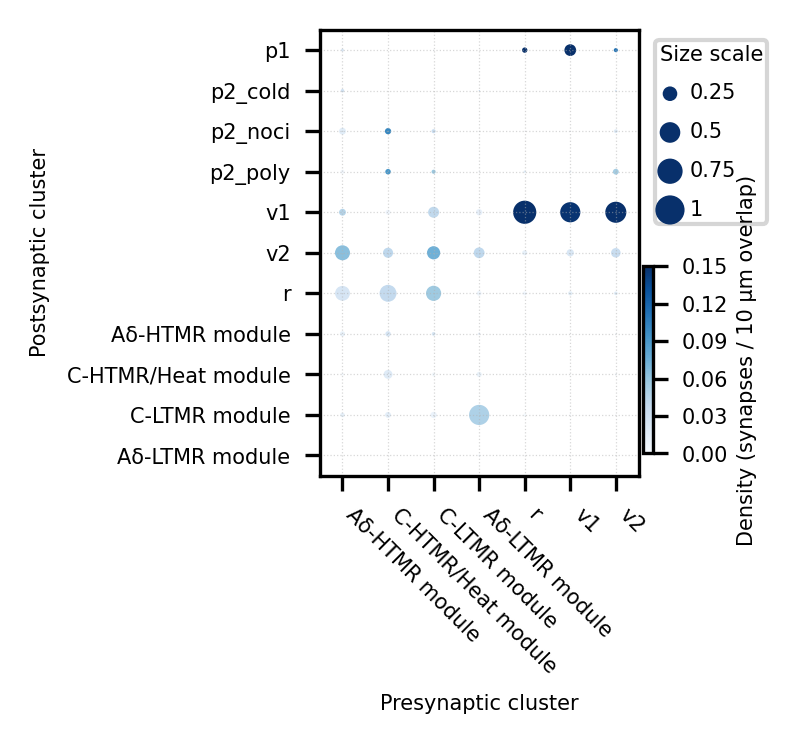

<ipython-input-27-83529dac77c6>:137: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = mpl.cm.get_cmap(cmap)
<ipython-input-27-83529dac77c6>:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj  = mpl.cm.get_cmap(cmap)


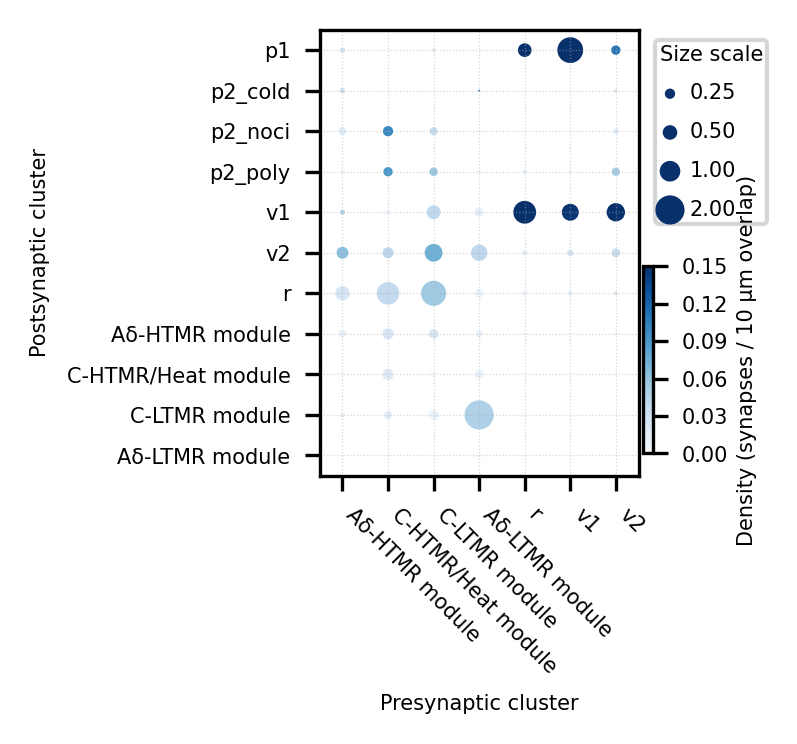

In [27]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------- Global tiny typography (all 5 pt) ----------
mpl.rcParams.update({
    "font.size": 5,
    "axes.titlesize": 5,
    "axes.labelsize": 5,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 5,
})

# ---- display remaps (TICK LABELS ONLY) ----
POST_LABEL_MAP = {
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}
PRE_LABEL_MAP = {
    "islet-chtmr": "Islet CHTMR/Heat",
    "islet-cltmr": "Islet C-LTMR",
    "islet-adltmr": "Islet Aδ-LTMR",
    "IN for abltmr": "IhN Aβ-LTMR",
    "IN for adhtmr": "IhN Aδ-HTMR",
    "IN for vertical cell": "IhN Vertical",
    # allow modules on x if they appear there
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}

# ---- helpers ----
def _prep_xy_and_vals(size_df, color_df, pre_order, post_order):
    size_df  = size_df.reindex(index=pre_order, columns=post_order)
    color_df = color_df.reindex(index=pre_order, columns=post_order)

    n_pre, n_post = len(pre_order), len(post_order)
    xs = np.repeat(np.arange(n_pre), n_post)
    ys = np.tile(np.arange(n_post), n_pre)

    svals  = size_df.to_numpy().ravel()
    cvals  = color_df.to_numpy().ravel()
    m = np.isfinite(svals) & np.isfinite(cvals)
    return xs[m], ys[m], svals[m], cvals[m], size_df, color_df

def _area_scaled_sizes(vals, max_area_pts2=400.0, size_vmax=None):
    vals = np.asarray(vals, float)
    if size_vmax is None:
        size_vmax = np.nanmax(vals) if np.any(np.isfinite(vals)) else 0.0
    if not np.isfinite(size_vmax) or size_vmax <= 0:
        return np.zeros_like(vals)
    return (vals / size_vmax) * max_area_pts2

def _fmt_abs(v):
    if v >= 1000:
        return f"{v:,.0f}"
    if v >= 10:
        return f"{v:.1f}"
    return f"{v:.2f}"

def _add_size_legend_outside(
    ax, *, size_vmax,
    ticks_rel=None, ticks_abs=None, labels=None,
    legend_max_diam_pts=7.0, cmap="viridis", legend_fontsize=5,
    bbox=(1.02, 1.0), legend_labelspacing=0.9, size_cap=None
):
    cmap_obj  = mpl.cm.get_cmap(cmap)
    max_color = cmap_obj(1.0)

    eff_vmax = size_vmax if (size_cap is None) else min(size_vmax, size_cap)

    if ticks_abs is not None:
        vals_for_markers = np.array(ticks_abs, float)
        if labels is None:
            labels = [_fmt_abs(v) for v in vals_for_markers]
    else:
        if ticks_rel is None:
            ticks_rel = (0, 0.25, 0.5, 0.75, 1.0)
        vals_for_markers = np.array(ticks_rel, float) * (eff_vmax if eff_vmax else 0.0)
        if labels is None:
            labels = [f"{t:g}" for t in ticks_rel]

    if size_cap is not None:
        vals_for_markers = np.minimum(vals_for_markers, size_cap)

    legend_max_area_pts2 = legend_max_diam_pts ** 2
    handles = [
        plt.scatter([], [], s=_area_scaled_sizes([v], max_area_pts2=legend_max_area_pts2, size_vmax=eff_vmax)[0],
                    edgecolors="none", linewidths=0.0, color=max_color)
        for v in vals_for_markers
    ]

    leg = ax.legend(
        handles, labels, title="Size scale",
        loc="upper left", bbox_to_anchor=bbox,
        frameon=True, borderpad=0.2, handletextpad=0.45,
        labelspacing=legend_labelspacing, handlelength=1.0, columnspacing=0.6,
        prop={"size": legend_fontsize}, title_fontsize=legend_fontsize
    )
    leg._legend_box.align = "left"

def bubble_grid(
    size_df, color_df, pre_order, post_order,
    title="", cmap="viridis", max_diam_pts=5.0, fig_cm=(6, 6),
    color_cap_percentile=95, color_vmin=None, size_vmax=None,
    size_cap=None, savepath=None, save_svg_path=None, save_bbox_tight=False,
    size_legend_ticks_abs=None, size_legend_ticks_rel=(0.25, 0.5, 0.75, 1.0), size_legend_labels=None,
    cbar_width_frac=0.02, cbar_height_frac=0.42, cbar_xpad_frac=0.01, cbar_yoffset_frac=0.05,
    pre_label_map=None, post_label_map=None,   # <-- NEW: display remaps
):
    """
    Bubble grid: **AREA ∝ size_df**, color ∝ color_df.
    Axis tick labels are optionally remapped for display via `pre_label_map`/`post_label_map`.
    """
    xs, ys, svals, cvals, size_df_a, color_df_a = _prep_xy_and_vals(
        size_df, color_df, pre_order, post_order
    )

    # ----- color normalization with cap (values unchanged) -----
    cvals_finite = cvals[np.isfinite(cvals)]
    if color_vmin is None:
        color_vmin = float(np.nanmin(cvals_finite)) if cvals_finite.size else 0.0
    if color_cap_percentile is None:
        color_vmax = float(np.nanmax(cvals_finite)) if cvals_finite.size else 1.0
    else:
        color_vmax = float(np.nanpercentile(cvals_finite, color_cap_percentile)) if cvals_finite.size else 1.0
    if color_vmax <= color_vmin:
        color_vmax = color_vmin + 1e-9

    norm = mpl.colors.Normalize(vmin=color_vmin, vmax=color_vmax)
    cmap_obj = mpl.cm.get_cmap(cmap)

    # ----- figure in centimeters -----
    fig_w_in, fig_h_in = fig_cm[0] / 2.54, fig_cm[1] / 2.54
    fig, ax = plt.subplots(figsize=(fig_w_in, fig_h_in), dpi=300)

    # ----- sizes: AREA scaling with optional cap -----
    if size_vmax is None:
        computed_vmax = float(np.nanmax(svals)) if np.any(np.isfinite(svals)) else 1.0
    else:
        computed_vmax = float(size_vmax)
    eff_vmax = computed_vmax if (size_cap is None) else min(computed_vmax, float(size_cap))

    svals_capped = np.minimum(svals, eff_vmax) if size_cap is not None else svals
    max_area_pts2 = (max_diam_pts ** 2)
    s_areas = _area_scaled_sizes(svals_capped, max_area_pts2=max_area_pts2, size_vmax=eff_vmax)

    sc = ax.scatter(
        xs, ys, s=s_areas, c=cvals, cmap=cmap_obj, norm=norm,
        edgecolors="none", linewidths=0.0
    )

    # axes & ticks
    ax.set_title(title)
    ax.set_xlabel("Presynaptic cluster")
    ax.set_ylabel("Postsynaptic cluster")
    ax.set_xticks(np.arange(len(pre_order)))
    ax.set_yticks(np.arange(len(post_order)))

    # ---- remap tick labels for display ONLY ----
    pre_labels_display  = [ (pre_label_map or {}).get(lbl,  lbl) for lbl in pre_order ]
    post_labels_display = [ (post_label_map or {}).get(lbl, lbl) for lbl in post_order ]
    ax.set_xticklabels(pre_labels_display, rotation=-45, ha="left")
    ax.set_yticklabels(post_labels_display)

    # heatmap-like orientation
    ax.set_xlim(-0.5, len(pre_order) - 0.5)
    ax.set_ylim(len(post_order) - 0.5, -0.5)
    ax.grid(which="both", linestyle=":", linewidth=0.3, alpha=0.5)

    # ---- leave room on the right for legend + cbar ----
    plt.subplots_adjust(right=0.80)

    # ---- size legend ----
    _add_size_legend_outside(
        ax,
        size_vmax=eff_vmax,
        ticks_rel=None if size_legend_ticks_abs is not None else size_legend_ticks_rel,
        ticks_abs=size_legend_ticks_abs,
        labels=size_legend_labels,
        legend_max_diam_pts=7.0,
        cmap=cmap,
        legend_fontsize=5,
        bbox=(1.02, 1.0),
        legend_labelspacing=0.9,
        size_cap=size_cap
    )

    # ---- vertical colorbar ----
    fig.canvas.draw()
    ax_pos = ax.get_position()
    cax = fig.add_axes([
        ax_pos.x1 + cbar_xpad_frac,
        ax_pos.y0 + ax_pos.height * cbar_yoffset_frac,
        cbar_width_frac,
        ax_pos.height * cbar_height_frac
    ])
    cbar = fig.colorbar(sc, cax=cax, orientation='vertical')
    ticks = np.linspace(color_vmin, color_vmax, 6)
    cbar.set_ticks(ticks)
    cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v*10:.2f}"))
    cbar.set_label("Density (synapses / 10 μm overlap)", labelpad=2, fontsize=5)
    cbar.ax.tick_params(labelsize=5)

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight' if save_bbox_tight else None)
    if save_svg_path:
        plt.savefig(save_svg_path, dpi=300, bbox_inches='tight' if save_bbox_tight else None)

    plt.show()

# 1) Fraction (area) + Density (color)
bubble_grid(
    fraction_cc, D_cc,
    pre_cluster_order, post_cluster_order,
    cmap="Blues",
    max_diam_pts=6.0,
    fig_cm=(4, 5),
    color_cap_percentile=95,
    size_vmax=1.0,
    pre_label_map=PRE_LABEL_MAP,     # <--- add remaps here
    post_label_map=POST_LABEL_MAP,   # <---
    # savepath="fraction_vs_density_6cm.png",
    # save_svg_path="fraction_vs_density_6cm.svg",
)

# 2) Avg synapses/pair (area) + Density (color), cap max bubble at 2
bubble_grid(
    A_avg_cc, D_cc,
    pre_cluster_order, post_cluster_order,
    cmap="Blues",
    max_diam_pts=7.0,
    fig_cm=(4, 5),
    color_cap_percentile=95,
    size_vmax=float(np.nanmax(A_avg_cc.to_numpy())),
    size_legend_ticks_abs=[0.25, 0.5, 1, 2],
    size_cap=2.0,
    pre_label_map=PRE_LABEL_MAP,     # <--- add remaps here
    post_label_map=POST_LABEL_MAP,   # <---
    # savepath="avgcount_vs_density_6cm.png",
    #save_svg_path="interneuron_matrix_figure4/bubble_grid_avg_count_011326.svg"
)


<ipython-input-27-83529dac77c6>:137: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = mpl.cm.get_cmap(cmap)
<ipython-input-27-83529dac77c6>:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj  = mpl.cm.get_cmap(cmap)


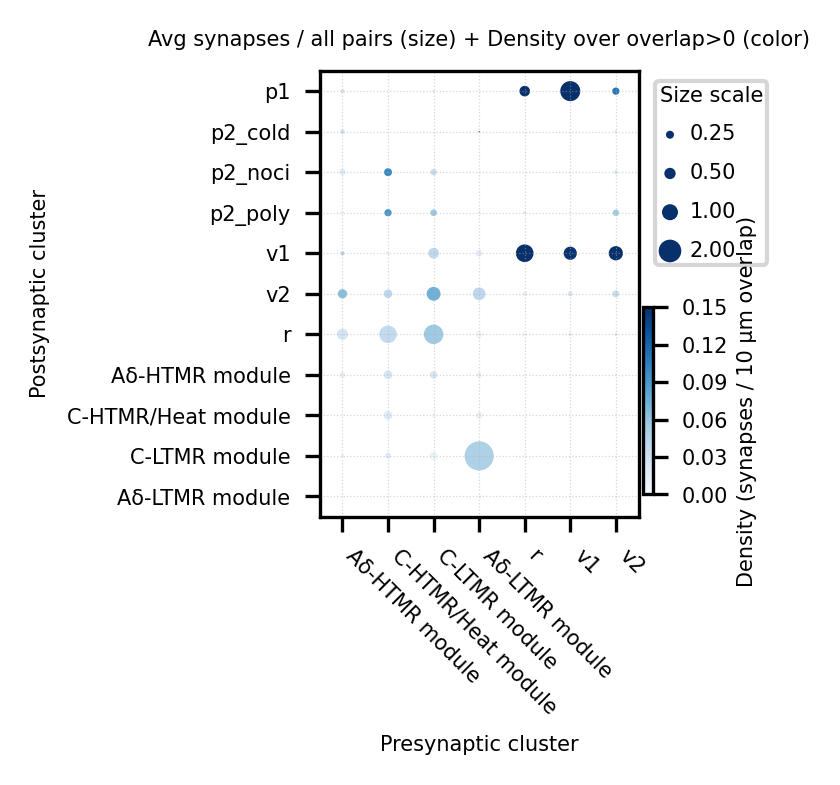

In [28]:
#when plotting the density, only consider the pairs have overlap
import numpy as np
import pandas as pd

# ---- choose your group/cluster orders (fallbacks if not defined) ----
pre_order  = pre_cluster_order  if 'pre_cluster_order'  in globals() else ["islet-chtmr","islet-cltmr","islet-adltmr","IN for adhtmr"]
post_order = post_cluster_order if 'post_cluster_order' in globals() else [
    "p1","p2_cold","p2_noci","p2_poly","v1","v2","r",
    "noci_module","np_module","cltmr_module","adltmr_module",
]

# ---- 1) Bring matrices to pres × post orientation & numeric ----
A = adjacency_df_completed.copy()
O = overlap_df.copy()

for X in (A, O):
    X.index = X.index.astype(str)
    X.columns = X.columns.astype(str)

# Auto-orient to pres(rows) × post(cols) using map membership
pre_ids  = set(pre_map.index.astype(str))
post_ids = set(post_map.index.astype(str))

row_in_pre  = sum(i in pre_ids  for i in A.index)
col_in_post = sum(j in post_ids for j in A.columns)
row_in_post = sum(i in post_ids for i in A.index)
col_in_pre  = sum(j in pre_ids  for j in A.columns)

if (row_in_post + col_in_pre) > (row_in_pre + col_in_post):
    # Looks like rows=posts, cols=pres → transpose both
    A = A.T
    O = O.T

# Align overlap to adjacency axes
O = O.reindex(index=A.index, columns=A.columns)

# Numeric coercion
A = A.apply(pd.to_numeric, errors="coerce")
O = O.apply(pd.to_numeric, errors="coerce")

# ---- 2) Build ID lists per tile ----
pre_map_s  = pre_map.astype(str)
post_map_s = post_map.astype(str)

ids_by_pre  = {g: pre_map_s[pre_map_s == g].index.astype(str).intersection(A.index)   for g in pre_order}
ids_by_post = {c: post_map_s[post_map_s == c].index.astype(str).intersection(A.columns) for c in post_order}

# ---- 3) Compute tile matrices ----
# D_overlaponly_avg:   mean density over overlap>0 ONLY
# A_allpairs_avg:      (sum of synapses) / (n_pre * n_post)  per tile
D_overlaponly_avg = pd.DataFrame(np.nan, index=pre_order, columns=post_order, dtype=float)
A_allpairs_avg    = pd.DataFrame(np.nan, index=pre_order, columns=post_order, dtype=float)

for g in pre_order:
    rows = list(ids_by_pre[g])
    n_pre = len(rows)
    for c in post_order:
        cols = list(ids_by_post[c])
        n_post = len(cols)

        if n_pre == 0 or n_post == 0:
            continue

        blockA = A.loc[rows, cols].to_numpy(dtype=float)
        blockO = O.loc[rows, cols].to_numpy(dtype=float)

        # ---- Color: density over overlap>0 only (synapses per μm overlap) ----
        with np.errstate(divide='ignore', invalid='ignore'):
            dens = np.divide(blockA, blockO, where=(blockO > 0))
        dens = np.where((blockO > 0) & np.isfinite(dens), dens, np.nan)
        D_overlaponly_avg.loc[g, c] = np.nanmean(dens) if np.isfinite(dens).any() else np.nan

        # ---- Size: avg synapses per ALL possible pairs in tile ----
        total_syn = float(np.nansum(np.where(np.isfinite(blockA), blockA, 0.0)))
        denom = n_pre * n_post
        A_allpairs_avg.loc[g, c] = total_syn / denom if denom > 0 else np.nan

# ---- 4) Plot: size = A_allpairs_avg, color = D_overlaponly_avg ----
bubble_grid(
    size_df=A_allpairs_avg,
    color_df=D_overlaponly_avg,
    pre_order=pre_order,
    post_order=post_order,
    title="Avg synapses / all pairs (size) + Density over overlap>0 (color)",
    cmap="Blues",
    max_diam_pts=7.0,
    fig_cm=(4, 5),
    color_cap_percentile=95,
    size_vmax=float(np.nanmax(A_allpairs_avg.to_numpy())) if np.isfinite(A_allpairs_avg.to_numpy()).any() else 1.0,
    size_legend_ticks_abs=[0.25, 0.5, 1, 2],
    #size_cap=2.0,
    pre_label_map=PRE_LABEL_MAP,
    post_label_map=POST_LABEL_MAP,
   #save_svg_path="interneuron_matrix_figure4/bubble_grid_avg_count_overlap_only_011326.svg"
)


In [29]:
import numpy as np
import pandas as pd

# Fixed colors you said you used before (from matplotlib "Blues")
BIN_TO_HEX = {
    0: "#c9ddf0",  # low
    1: "#77b5d9",  # mid
    2: "#083e81",  # high
}

def recapture_specs_df_fixed_hex(
    A_avg_cc: pd.DataFrame,
    D_cc_overlaponly: pd.DataFrame,
    pre_order,
    post_order,
    *,
    avg_thresh=0.10,
    dens_thresh=0.0036,
    size_bins=(0.10, 0.25, 0.50, 1.00, np.inf),
    arrow_sizes_pts=(0.5, 1.0, 2.0, 3.0),
    color_bin_edges=(0.0036, 0.007, 0.014),
):
    # Align
    A = A_avg_cc.reindex(index=pre_order, columns=post_order).astype(float)
    D = D_cc_overlaponly.reindex(index=pre_order, columns=post_order).astype(float)

    # Long table (RAW values)
    df = pd.DataFrame({
        "pre":  np.repeat(list(pre_order), len(post_order)),
        "post": list(post_order) * len(pre_order),
        "A_avg": A.to_numpy().ravel(),
        "dens_raw": D.to_numpy().ravel(),   # overlap-only density
    }).dropna(subset=["A_avg", "dens_raw"])

    # Plot rule (IMPORTANT: threshold uses dens_raw, not binned)
    df = df[(df["A_avg"] >= avg_thresh) & (df["dens_raw"] >= dens_thresh)].copy()

    # ---- size bins -> arrow size (pts) ----
    if len(arrow_sizes_pts) != (len(size_bins) - 1):
        raise ValueError("arrow_sizes_pts must have length len(size_bins)-1")

    size_edges = np.array(size_bins, dtype=float)
    s_idx = np.digitize(df["A_avg"].to_numpy(), size_edges, right=False) - 1
    s_idx = np.clip(s_idx, 0, len(arrow_sizes_pts) - 1)
    df["arrow_size_pts"] = np.array(arrow_sizes_pts, dtype=float)[s_idx]

    # ---- density bins -> 0/1/2 -> fixed hex ----
    edges = np.array(color_bin_edges, dtype=float)  # (e0,e1,e2)
    d_idx = np.digitize(df["dens_raw"].to_numpy(), edges, right=False) - 1
    d_idx = np.clip(d_idx, 0, 2)
    df["dens_bin"] = d_idx
    df["color_hex"] = [BIN_TO_HEX[int(i)] for i in d_idx]

    # (optional) store the representative bin value for debugging
    reps = np.array([edges[0], edges[1], edges[2]], dtype=float)
    df["dens_bin_value"] = reps[d_idx]

    return df.sort_values(["pre", "post"]).reset_index(drop=True)

# ---- run with your rule params ----
specs_for_wiring = recapture_specs_df_fixed_hex(
    A_avg_cc,
    D_cc_overlaponly,
    pre_cluster_order,
    post_cluster_order,
    avg_thresh=0.10,
    dens_thresh=0.0036,
    size_bins=(0.10, 0.25, 0.50, 1.00, np.inf),
    arrow_sizes_pts=(0.5, 1, 2, 3),
    color_bin_edges=(0.0036, 0.007, 0.014),
)

display(specs_for_wiring[["pre","post","A_avg","dens_raw","arrow_size_pts","dens_bin","dens_bin_value","color_hex"]])


,pre,post,A_avg,dens_raw,arrow_size_pts,dens_bin,dens_bin_value,color_hex
0,adltmr_module,cltmr_module,3.316667,0.004947,3.0,0,0.0036,#c9ddf0
1,adltmr_module,v2,0.629630,0.004103,2.0,0,0.0036,#c9ddf0
2,cltmr_module,p2_poly,0.169444,0.005850,0.5,0,0.0036,#c9ddf0
3,cltmr_module,r,1.477431,0.005666,3.0,0,0.0036,#c9ddf0
4,cltmr_module,v1,0.454268,0.004079,1.0,0,0.0036,#c9ddf0
5,cltmr_module,v2,0.746528,0.007437,2.0,1,0.0070,#77b5d9
6,noci_module,v2,0.333333,0.006413,1.0,0,0.0036,#c9ddf0
7,np_module,p2_noci,0.245370,0.010060,0.5,1,0.0070,#77b5d9
8,np_module,p2_poly,0.204938,0.009163,0.5,1,0.0070,#77b5d9
9,np_module,r,1.205247,0.003894,3.0,0,0.0036,#c9ddf0


In [30]:
from pathlib import Path

# Output directory
out_dir = Path("/Users/wangchu/connectivity_analysis/adjacency_overlap_matrix_070826")
out_dir.mkdir(parents=True, exist_ok=True)

# Make sure IDs are stored as strings
overlap_df.index = overlap_df.index.astype(str)
overlap_df.columns = overlap_df.columns.astype(str)

adjacency_df_completed.index = adjacency_df_completed.index.astype(str)
adjacency_df_completed.columns = adjacency_df_completed.columns.astype(str)

# Save
overlap_df.to_csv(out_dir / "overlap_matrix.csv")
adjacency_df_completed.to_csv(out_dir / "adjacency_matrix.csv")

print("Saved:")
print(out_dir / "overlap_matrix.csv")
print(out_dir / "adjacency_matrix.csv")

Saved:
/Users/wangchu/connectivity_analysis/adjacency_overlap_matrix_070826/overlap_matrix.csv
/Users/wangchu/connectivity_analysis/adjacency_overlap_matrix_070826/adjacency_matrix.csv


In [31]:
import numpy as np
import pandas as pd

celltype_stats = []

for g in pre_order:
    rows = list(ids_by_pre[g])
    n_pre = len(rows)

    for c in post_order:
        cols = list(ids_by_post[c])
        n_post = len(cols)

        if n_pre == 0 or n_post == 0:
            continue

        blockA = A.loc[rows, cols].to_numpy(dtype=float)
        blockO = O.loc[rows, cols].to_numpy(dtype=float)

        with np.errstate(divide="ignore", invalid="ignore"):
            dens = np.divide(blockA, blockO, where=(blockO > 0))

        dens = np.where((blockO > 0) & np.isfinite(dens), dens, np.nan)

        A_vals = blockA[np.isfinite(blockA)]
        D_vals = dens[np.isfinite(dens)]

        celltype_stats.append({
            "pre": g,
            "post": c,
            "n_pre": n_pre,
            "n_post": n_post,
            "n_pairs": n_pre * n_post,
            "A_avg": np.nanmean(A_vals) if A_vals.size else np.nan,
            "A_std": np.nanstd(A_vals, ddof=1) if A_vals.size > 1 else np.nan,
            "dens_raw": np.nanmean(D_vals) if D_vals.size else np.nan,
            "dens_std": np.nanstd(D_vals, ddof=1) if D_vals.size > 1 else np.nan,
            "n_overlap_pairs": D_vals.size,
        })

celltype_stats_df = pd.DataFrame(celltype_stats)

display(celltype_stats_df)

,pre,post,n_pre,n_post,n_pairs,A_avg,A_std,dens_raw,dens_std,n_overlap_pairs
0,noci_module,p1,10,6,60,0.066667,0.406167,0.002592,0.015549,36
1,noci_module,p2_cold,10,9,90,0.066667,0.292221,0.003067,0.008267,30
2,noci_module,p2_noci,10,16,160,0.156250,0.555667,0.001711,0.005600,95
3,noci_module,p2_poly,10,15,150,0.053333,0.253477,0.000441,0.001570,75
4,noci_module,v1,10,41,410,0.060976,0.446326,0.004611,0.050207,241
...,...,...,...,...,...,...,...,...,...,...
72,v2,r,36,24,864,0.039352,0.305724,0.001778,0.015229,441
73,v2,noci_module,36,10,360,0.016667,0.182065,0.000416,0.004103,245
74,v2,np_module,36,27,972,0.011317,0.131831,0.000399,0.004141,391
75,v2,cltmr_module,36,24,864,0.002315,0.048085,0.000084,0.001496,411


In [33]:
celltype_stats_df.to_csv(
    "/Users/wangchu/connectivity_analysis/adjacency_overlap_matrix_070826/celltype_stats.csv",
    index=False,
)

In [34]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# Cell type × cell type pair summary
# Reports:
# 1. number of possible pairs
# 2. number of pairs with synapses
# 3. number of pairs with path overlap
# 4. total synapses
# --------------------------------------------------

celltype_pair_stats = []

for pre_type in pre_order:
    pre_ids_this = list(ids_by_pre[pre_type])
    n_pre = len(pre_ids_this)

    for post_type in post_order:
        post_ids_this = list(ids_by_post[post_type])
        n_post = len(post_ids_this)

        if n_pre == 0 or n_post == 0:
            continue

        blockA = A.loc[pre_ids_this, post_ids_this].to_numpy(dtype=float)
        blockO = O.loc[pre_ids_this, post_ids_this].to_numpy(dtype=float)

        n_possible_pairs = n_pre * n_post

        n_pairs_with_synapses = int(np.sum(np.isfinite(blockA) & (blockA > 0)))
        n_pairs_with_overlap = int(np.sum(np.isfinite(blockO) & (blockO > 0)))

        total_synapses = float(np.nansum(blockA))

        celltype_pair_stats.append({
            "pre": pre_type,
            "post": post_type,
            "n_pre": n_pre,
            "n_post": n_post,
            "n_possible_pairs": n_possible_pairs,
            "n_pairs_with_synapses": n_pairs_with_synapses,
            "n_pairs_with_overlap": n_pairs_with_overlap,
            "total_synapses": total_synapses,
            "fraction_pairs_with_synapses": n_pairs_with_synapses / n_possible_pairs,
            "fraction_pairs_with_overlap": n_pairs_with_overlap / n_possible_pairs,
        })

celltype_pair_stats_df = pd.DataFrame(celltype_pair_stats)

display(celltype_pair_stats_df)

,pre,post,n_pre,n_post,n_possible_pairs,n_pairs_with_synapses,n_pairs_with_overlap,total_synapses,fraction_pairs_with_synapses,fraction_pairs_with_overlap
0,noci_module,p1,10,6,60,2,36,4.0,0.033333,0.600000
1,noci_module,p2_cold,10,9,90,5,30,6.0,0.055556,0.333333
2,noci_module,p2_noci,10,16,160,16,95,25.0,0.100000,0.593750
3,noci_module,p2_poly,10,15,150,7,75,8.0,0.046667,0.500000
4,noci_module,v1,10,41,410,12,241,25.0,0.029268,0.587805
...,...,...,...,...,...,...,...,...,...,...
72,v2,r,36,24,864,22,441,34.0,0.025463,0.510417
73,v2,noci_module,36,10,360,4,245,6.0,0.011111,0.680556
74,v2,np_module,36,27,972,9,391,11.0,0.009259,0.402263
75,v2,cltmr_module,36,24,864,2,411,2.0,0.002315,0.475694


In [35]:
celltype_pair_stats_df.to_csv(
    "/Users/wangchu/connectivity_analysis/adjacency_overlap_matrix_070826/celltype_pair_counts.csv",
    index=False,
)

,pre,post,n_pre,n_post,n_possible_pairs,n_connected_pairs,n_overlap_pairs,total_synapses,avg_syn_per_connected_pair,avg_syn_per_overlap_pair,density_overlaponly_syn_per_um
0,noci_module,p1,10,6,60,2,36,4.0,2.000000,0.111111,0.002592
1,noci_module,p2_cold,10,9,90,5,30,6.0,1.200000,0.200000,0.003067
2,noci_module,p2_noci,10,16,160,16,95,25.0,1.562500,0.263158,0.001711
3,noci_module,p2_poly,10,15,150,7,75,8.0,1.142857,0.106667,0.000441
4,noci_module,v1,10,41,410,12,241,25.0,2.083333,0.103734,0.004611
...,...,...,...,...,...,...,...,...,...,...,...
72,v2,r,36,24,864,22,441,34.0,1.545455,0.077098,0.001778
73,v2,noci_module,36,10,360,4,245,6.0,1.500000,0.024490,0.000416
74,v2,np_module,36,27,972,9,391,11.0,1.222222,0.028133,0.000399
75,v2,cltmr_module,36,24,864,2,411,2.0,1.000000,0.004866,0.000084


<ipython-input-27-83529dac77c6>:137: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = mpl.cm.get_cmap(cmap)
<ipython-input-27-83529dac77c6>:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj  = mpl.cm.get_cmap(cmap)


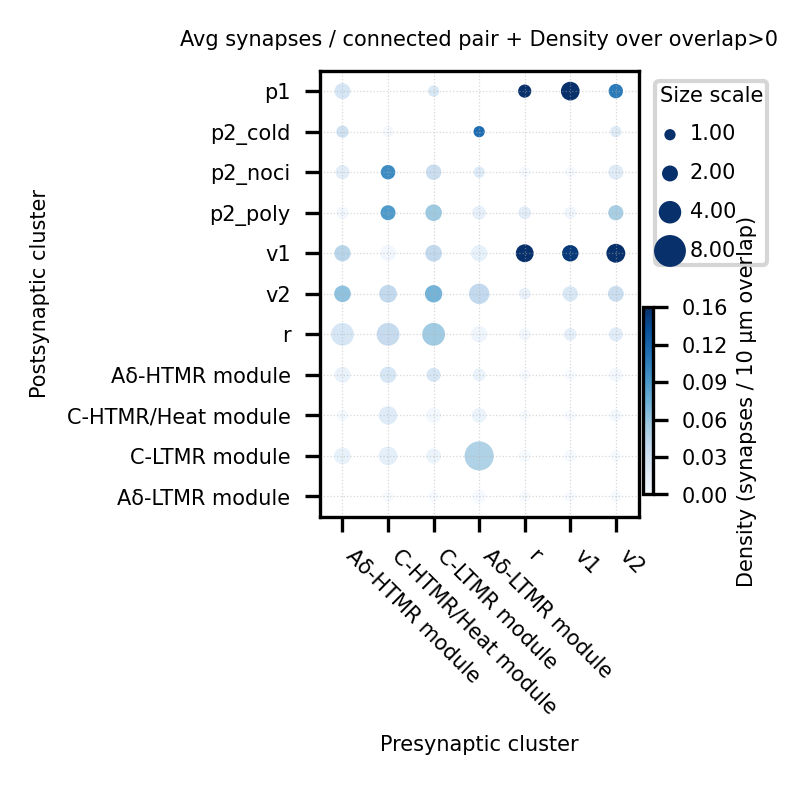

<ipython-input-27-83529dac77c6>:137: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = mpl.cm.get_cmap(cmap)
<ipython-input-27-83529dac77c6>:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj  = mpl.cm.get_cmap(cmap)


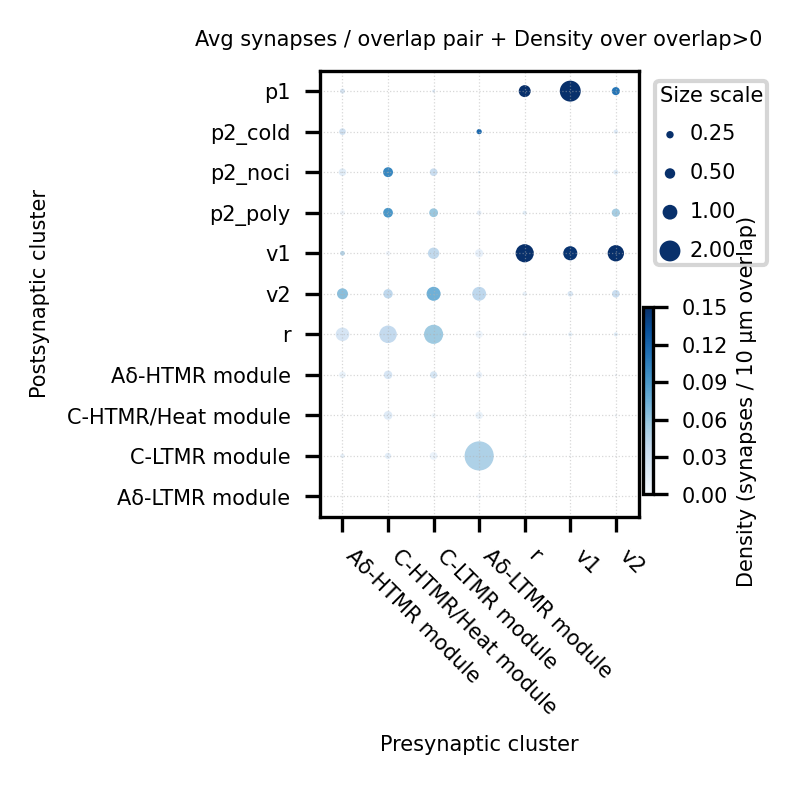

In [53]:
# note the second plot is the one used for the paper
import numpy as np
import pandas as pd

# --------------------------------------------------
# 0) Choose group / cluster orders
# --------------------------------------------------

pre_order = pre_cluster_order if "pre_cluster_order" in globals() else [
    "islet-chtmr",
    "islet-cltmr",
    "islet-adltmr",
    "IN for adhtmr",
]

post_order = post_cluster_order if "post_cluster_order" in globals() else [
    "p1", "p2_cold", "p2_noci", "p2_poly", "v1", "v2", "r",
    "noci_module", "np_module", "cltmr_module", "adltmr_module",
]


# --------------------------------------------------
# 1) Bring matrices to presynaptic × postsynaptic orientation
# --------------------------------------------------

A = adjacency_df_completed.copy()
O = overlap_df.copy()

for X in (A, O):
    X.index = X.index.astype(str)
    X.columns = X.columns.astype(str)

pre_ids = set(pre_map.index.astype(str))
post_ids = set(post_map.index.astype(str))

row_in_pre = sum(i in pre_ids for i in A.index)
col_in_post = sum(j in post_ids for j in A.columns)
row_in_post = sum(i in post_ids for i in A.index)
col_in_pre = sum(j in pre_ids for j in A.columns)

if (row_in_post + col_in_pre) > (row_in_pre + col_in_post):
    # rows=posts, cols=pres -> transpose both
    A = A.T
    O = O.T

# Align overlap matrix to adjacency matrix
O = O.reindex(index=A.index, columns=A.columns)

# Numeric coercion
A = A.apply(pd.to_numeric, errors="coerce")
O = O.apply(pd.to_numeric, errors="coerce")


# --------------------------------------------------
# 2) Build neuron ID lists for each pre/post cell type
# --------------------------------------------------

pre_map_s = pre_map.astype(str)
post_map_s = post_map.astype(str)

ids_by_pre = {
    g: pre_map_s[pre_map_s == g].index.astype(str).intersection(A.index)
    for g in pre_order
}

ids_by_post = {
    c: post_map_s[post_map_s == c].index.astype(str).intersection(A.columns)
    for c in post_order
}


# --------------------------------------------------
# 3) Compute cell type × cell type matrices
# --------------------------------------------------

# Color: density over pairs with overlap only
# units: synapses / μm overlap
D_overlaponly_avg = pd.DataFrame(
    np.nan,
    index=pre_order,
    columns=post_order,
    dtype=float,
)

# Size option 1:
# average synapses only among connected pairs, i.e. blockA > 0
A_connectedpairs_avg = pd.DataFrame(
    np.nan,
    index=pre_order,
    columns=post_order,
    dtype=float,
)

# Size option 2:
# average synapses only among pairs with path overlap, i.e. blockO > 0
A_overlappairs_avg = pd.DataFrame(
    np.nan,
    index=pre_order,
    columns=post_order,
    dtype=float,
)

# Optional diagnostic counts
celltype_pair_counts = []

for g in pre_order:
    rows = list(ids_by_pre[g])
    n_pre = len(rows)

    for c in post_order:
        cols = list(ids_by_post[c])
        n_post = len(cols)

        if n_pre == 0 or n_post == 0:
            continue

        blockA = A.loc[rows, cols].to_numpy(dtype=float)
        blockO = O.loc[rows, cols].to_numpy(dtype=float)

        validA = np.isfinite(blockA)
        validO = np.isfinite(blockO)

        syn_mask = validA & (blockA > 0)
        overlap_mask = validO & (blockO > 0)

        total_syn = float(np.nansum(np.where(validA, blockA, 0.0)))

        n_possible_pairs = n_pre * n_post
        n_connected_pairs = int(np.sum(syn_mask))
        n_overlap_pairs = int(np.sum(overlap_mask))

        # --------------------------------------------------
        # Density: synapses / μm, only for pairs with overlap
        # --------------------------------------------------

        with np.errstate(divide="ignore", invalid="ignore"):
            dens = np.divide(blockA, blockO, where=overlap_mask)

        dens = np.where(
            overlap_mask & np.isfinite(dens),
            dens,
            np.nan,
        )

        if np.isfinite(dens).any():
            D_overlaponly_avg.loc[g, c] = np.nanmean(dens)

        # --------------------------------------------------
        # Average synapses per connected pair
        # denominator = number of pairs with >=1 synapse
        # --------------------------------------------------

        if n_connected_pairs > 0:
            A_connectedpairs_avg.loc[g, c] = total_syn / n_connected_pairs

        # --------------------------------------------------
        # Average synapses per overlap pair
        # denominator = number of pairs with path overlap
        # --------------------------------------------------

        if n_overlap_pairs > 0:
            A_overlappairs_avg.loc[g, c] = total_syn / n_overlap_pairs

        celltype_pair_counts.append({
            "pre": g,
            "post": c,
            "n_pre": n_pre,
            "n_post": n_post,
            "n_possible_pairs": n_possible_pairs,
            "n_connected_pairs": n_connected_pairs,
            "n_overlap_pairs": n_overlap_pairs,
            "total_synapses": total_syn,
            "avg_syn_per_connected_pair": A_connectedpairs_avg.loc[g, c],
            "avg_syn_per_overlap_pair": A_overlappairs_avg.loc[g, c],
            "density_overlaponly_syn_per_um": D_overlaponly_avg.loc[g, c],
        })

celltype_pair_counts_df = pd.DataFrame(celltype_pair_counts)

display(celltype_pair_counts_df)


# --------------------------------------------------
# 4) Plot 1: size = average synapses per connected pair
# --------------------------------------------------

size_vmax_connected = (
    float(np.nanmax(A_connectedpairs_avg.to_numpy()))
    if np.isfinite(A_connectedpairs_avg.to_numpy()).any()
    else 1.0
)

bubble_grid(
    size_df=A_connectedpairs_avg,
    color_df=D_overlaponly_avg,
    pre_order=pre_order,
    post_order=post_order,
    title="Avg synapses / connected pair + Density over overlap>0",
    cmap="Blues",
    max_diam_pts=7.0,
    fig_cm=(4, 5),
    color_cap_percentile=95,
    size_vmax=size_vmax_connected,
    size_legend_ticks_abs=[1, 2, 4, 8],
    pre_label_map=PRE_LABEL_MAP,
    post_label_map=POST_LABEL_MAP,
    # save_svg_path="interneuron_matrix_figure4/bubble_grid_connected_pair_avg.svg",
)


# --------------------------------------------------
# 5) Plot 2: size = average synapses per overlap pair
# --------------------------------------------------

size_vmax_overlap = (
    float(np.nanmax(A_overlappairs_avg.to_numpy()))
    if np.isfinite(A_overlappairs_avg.to_numpy()).any()
    else 1.0
)

bubble_grid(
    size_df=A_overlappairs_avg,
    color_df=D_overlaponly_avg,
    pre_order=pre_order,
    post_order=post_order,
    title="Avg synapses / overlap pair + Density over overlap>0",
    cmap="Blues",
    max_diam_pts=7.0,
    fig_cm=(4, 5),
    color_cap_percentile=95,
    size_vmax=size_vmax_overlap,
    size_legend_ticks_abs=[0.25, 0.5, 1, 2],
    pre_label_map=PRE_LABEL_MAP,
    post_label_map=POST_LABEL_MAP,
    save_svg_path="interneuron_matrix_figure4/bubble_grid_overlap_pair_avg_070926.svg",
)

In [38]:
# --------------------------------------------------
# Rename and save summary table
# --------------------------------------------------

celltype_count_overlaponly_df = pd.DataFrame(celltype_pair_counts)

display(celltype_count_overlaponly_df)

celltype_count_overlaponly_df.to_csv(
    "/Users/wangchu/connectivity_analysis/adjacency_overlap_matrix_070826/celltype_count_overlaponly.csv",
    index=False,
)

print("Saved:")
print("/Users/wangchu/connectivity_analysis/adjacency_overlap_matrix_070826/celltype_count_overlaponly.csv")

,pre,post,n_pre,n_post,n_possible_pairs,n_connected_pairs,n_overlap_pairs,total_synapses,avg_syn_per_connected_pair,avg_syn_per_overlap_pair,density_overlaponly_syn_per_um
0,noci_module,p1,10,6,60,2,36,4.0,2.000000,0.111111,0.002592
1,noci_module,p2_cold,10,9,90,5,30,6.0,1.200000,0.200000,0.003067
2,noci_module,p2_noci,10,16,160,16,95,25.0,1.562500,0.263158,0.001711
3,noci_module,p2_poly,10,15,150,7,75,8.0,1.142857,0.106667,0.000441
4,noci_module,v1,10,41,410,12,241,25.0,2.083333,0.103734,0.004611
...,...,...,...,...,...,...,...,...,...,...,...
72,v2,r,36,24,864,22,441,34.0,1.545455,0.077098,0.001778
73,v2,noci_module,36,10,360,4,245,6.0,1.500000,0.024490,0.000416
74,v2,np_module,36,27,972,9,391,11.0,1.222222,0.028133,0.000399
75,v2,cltmr_module,36,24,864,2,411,2.0,1.000000,0.004866,0.000084


Saved:
/Users/wangchu/connectivity_analysis/adjacency_overlap_matrix_070826/celltype_count_overlaponly.csv


In [39]:
import numpy as np
import pandas as pd

# Fixed colors (matplotlib Blues)
BIN_TO_HEX = {
    0: "#c9ddf0",
    1: "#77b5d9",
    2: "#083e81",
}

def recapture_specs_df_overlaponly(
    A_overlap_avg: pd.DataFrame,
    D_overlap_avg: pd.DataFrame,
    pre_order,
    post_order,
    *,
    avg_thresh=0.10,
    dens_thresh=0.0036,
    size_bins=(0.10, 0.25, 0.50, 1.00, np.inf),
    arrow_sizes_pts=(0.5, 1.0, 2.0, 3.0),
    color_bin_edges=(0.0036, 0.007, 0.014),
):

    # Align matrices
    A = A_overlap_avg.reindex(index=pre_order, columns=post_order).astype(float)
    D = D_overlap_avg.reindex(index=pre_order, columns=post_order).astype(float)

    # Long-format table
    df = pd.DataFrame({
        "pre": np.repeat(list(pre_order), len(post_order)),
        "post": list(post_order) * len(pre_order),
        "avg_syn_per_overlap_pair": A.to_numpy().ravel(),
        "density_syn_per_um": D.to_numpy().ravel(),
    }).dropna(subset=["avg_syn_per_overlap_pair", "density_syn_per_um"])

    # Thresholding (easy to change later)
    df = df[
        (df["avg_syn_per_overlap_pair"] >= avg_thresh) &
        (df["density_syn_per_um"] >= dens_thresh)
    ].copy()

    # ---------------------------
    # Size bins
    # ---------------------------

    if len(arrow_sizes_pts) != (len(size_bins) - 1):
        raise ValueError("arrow_sizes_pts must have length len(size_bins)-1")

    size_edges = np.asarray(size_bins, dtype=float)

    size_idx = np.digitize(
        df["avg_syn_per_overlap_pair"].to_numpy(),
        size_edges,
        right=False
    ) - 1

    size_idx = np.clip(size_idx, 0, len(arrow_sizes_pts)-1)

    df["arrow_size_pts"] = np.asarray(arrow_sizes_pts)[size_idx]

    # ---------------------------
    # Density bins
    # ---------------------------

    edges = np.asarray(color_bin_edges, dtype=float)

    dens_idx = np.digitize(
        df["density_syn_per_um"].to_numpy(),
        edges,
        right=False
    ) - 1

    dens_idx = np.clip(dens_idx, 0, 2)

    df["dens_bin"] = dens_idx
    df["color_hex"] = [BIN_TO_HEX[int(i)] for i in dens_idx]

    reps = np.array(edges)

    df["dens_bin_value"] = reps[dens_idx]

    return df.sort_values(["pre", "post"]).reset_index(drop=True)

In [52]:
specs_for_wiring_overlaponly = recapture_specs_df_overlaponly(
    A_overlap_avg=A_overlappairs_avg,
    D_overlap_avg=D_overlaponly_avg,
    pre_order=pre_cluster_order,
    post_order=post_cluster_order,

    # easy to tune later
    avg_thresh=0.25,
    dens_thresh=0.0036,

    size_bins=(0.25, 0.5, 1, 2, np.inf),
    arrow_sizes_pts=(0.5, 1, 2, 4),

    color_bin_edges=(0.0036, 0.007, 0.014),
)

display(
    specs_for_wiring_overlaponly[
        [
            "pre",
            "post",
            "avg_syn_per_overlap_pair",
            "density_syn_per_um",
            "arrow_size_pts",
            "dens_bin",
            "dens_bin_value",
            "color_hex",
        ]
    ]
)

,pre,post,avg_syn_per_overlap_pair,density_syn_per_um,arrow_size_pts,dens_bin,dens_bin_value,color_hex
0,adltmr_module,cltmr_module,3.901961,0.004947,4.0,0,0.0036,#c9ddf0
1,adltmr_module,v2,0.887728,0.004103,1.0,0,0.0036,#c9ddf0
2,cltmr_module,p2_poly,0.356725,0.005850,0.5,0,0.0036,#c9ddf0
3,cltmr_module,r,1.678501,0.005666,2.0,0,0.0036,#c9ddf0
4,cltmr_module,v1,0.591270,0.004079,1.0,0,0.0036,#c9ddf0
5,cltmr_module,v2,0.899582,0.007437,1.0,1,0.0070,#77b5d9
6,noci_module,v2,0.550459,0.006413,1.0,0,0.0036,#c9ddf0
7,np_module,p2_noci,0.449153,0.010060,0.5,1,0.0070,#77b5d9
8,np_module,p2_poly,0.432292,0.009163,0.5,1,0.0070,#77b5d9
9,np_module,r,1.404676,0.003894,2.0,0,0.0036,#c9ddf0


In [54]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# Define groups
# --------------------------------------------------

sensory_modules = [
    "noci_module",
    "np_module",
    "cltmr_module",
    "adltmr_module",
]

target_cells = [
    "r",
    "v2",
]

# ExN module pairs = sensory module -> sensory module
exn_module_pre_order = sensory_modules
exn_module_post_order = sensory_modules

# Sensory module -> radial / Vert2
sensory_to_target_pre_order = sensory_modules
sensory_to_target_post_order = target_cells


# --------------------------------------------------
# Make sure matrices are presynaptic x postsynaptic
# --------------------------------------------------

A = adjacency_df_completed.copy()
O = overlap_df.copy()

A.index = A.index.astype(str)
A.columns = A.columns.astype(str)
O.index = O.index.astype(str)
O.columns = O.columns.astype(str)

pre_ids = set(pre_map.index.astype(str))
post_ids = set(post_map.index.astype(str))

row_in_pre = sum(i in pre_ids for i in A.index)
col_in_post = sum(j in post_ids for j in A.columns)
row_in_post = sum(i in post_ids for i in A.index)
col_in_pre = sum(j in pre_ids for j in A.columns)

if (row_in_post + col_in_pre) > (row_in_pre + col_in_post):
    A = A.T
    O = O.T

O = O.reindex(index=A.index, columns=A.columns)

A = A.apply(pd.to_numeric, errors="coerce")
O = O.apply(pd.to_numeric, errors="coerce")


# --------------------------------------------------
# Build cell-type ID maps
# --------------------------------------------------

pre_map_s = pre_map.astype(str)
post_map_s = post_map.astype(str)

def ids_for_pre(celltype):
    return pre_map_s[pre_map_s == celltype].index.astype(str).intersection(A.index)

def ids_for_post(celltype):
    return post_map_s[post_map_s == celltype].index.astype(str).intersection(A.columns)


# --------------------------------------------------
# Function to compute average synapse density
# --------------------------------------------------

def compute_avg_density_matrix(pre_groups, post_groups, density_scale=1.0):
    """
    Computes average synapse density for each pre x post cell-type pair.

    Density is computed only for neuron pairs with path overlap > 0:
        density = synapse_count / path_overlap_um

    density_scale:
        1.0  = synapses / 1 um
        10.0 = synapses / 10 um
    """

    density_avg = pd.DataFrame(
        np.nan,
        index=pre_groups,
        columns=post_groups,
        dtype=float,
    )

    density_std = pd.DataFrame(
        np.nan,
        index=pre_groups,
        columns=post_groups,
        dtype=float,
    )

    density_n = pd.DataFrame(
        0,
        index=pre_groups,
        columns=post_groups,
        dtype=int,
    )

    for pre_type in pre_groups:
        rows = list(ids_for_pre(pre_type))

        for post_type in post_groups:
            cols = list(ids_for_post(post_type))

            if len(rows) == 0 or len(cols) == 0:
                continue

            blockA = A.loc[rows, cols].to_numpy(dtype=float)
            blockO = O.loc[rows, cols].to_numpy(dtype=float)

            overlap_mask = np.isfinite(blockO) & (blockO > 0)

            with np.errstate(divide="ignore", invalid="ignore"):
                dens = np.divide(blockA, blockO, where=overlap_mask)

            dens = np.where(
                overlap_mask & np.isfinite(dens),
                dens * density_scale,
                np.nan,
            )

            vals = dens[np.isfinite(dens)]

            if vals.size > 0:
                density_avg.loc[pre_type, post_type] = np.mean(vals)
                density_std.loc[pre_type, post_type] = np.std(vals, ddof=1) if vals.size > 1 else np.nan
                density_n.loc[pre_type, post_type] = vals.size

    return density_avg, density_std, density_n


# --------------------------------------------------
# 1) ExN module -> ExN module density
# --------------------------------------------------

exn_module_density_avg, exn_module_density_std, exn_module_density_n = compute_avg_density_matrix(
    exn_module_pre_order,
    exn_module_post_order,
    density_scale=10.0,   # synapses / 10 um
)

print("ExN module -> ExN module density avg, synapses / 10 um overlap")
display(exn_module_density_avg)

print("ExN module -> ExN module density std, synapses / 10 um overlap")
display(exn_module_density_std)

print("ExN module -> ExN module n overlap pairs")
display(exn_module_density_n)


# --------------------------------------------------
# 2) Sensory module -> radial / Vert2 density
# --------------------------------------------------

sensory_to_target_density_avg, sensory_to_target_density_std, sensory_to_target_density_n = compute_avg_density_matrix(
    sensory_to_target_pre_order,
    sensory_to_target_post_order,
    density_scale=10.0,   # synapses / 10 um
)

print("Sensory module -> radial / Vert2 density avg, synapses / 10 um overlap")
display(sensory_to_target_density_avg)

print("Sensory module -> radial / Vert2 density std, synapses / 10 um overlap")
display(sensory_to_target_density_std)

print("Sensory module -> radial / Vert2 n overlap pairs")
display(sensory_to_target_density_n)

ExN module -> ExN module density avg, synapses / 10 um overlap


,noci_module,np_module,cltmr_module,adltmr_module
noci_module,0.011134,0.002999,0.012362,0.000000
np_module,0.024802,0.018911,0.014863,0.000169
cltmr_module,0.025319,0.003717,0.009144,0.000336
adltmr_module,0.010456,0.009658,0.049474,0.001053


ExN module -> ExN module density std, synapses / 10 um overlap


,noci_module,np_module,cltmr_module,adltmr_module
noci_module,0.037723,0.030010,0.089848,0.000000
np_module,0.128586,0.085979,0.102934,0.002697
cltmr_module,0.147477,0.020365,0.027526,0.004053
adltmr_module,0.036457,0.028784,0.077125,0.005781


ExN module -> ExN module n overlap pairs


...

,r,v2
noci_module,0.026025,0.064132
np_module,0.038945,0.041188
cltmr_module,0.056660,0.074373
adltmr_module,0.006914,0.041030


Sensory module -> radial / Vert2 density std, synapses / 10 um overlap


,r,v2
noci_module,0.065599,0.185804
np_module,0.080933,0.151488
cltmr_module,0.135745,0.185053
adltmr_module,0.038923,0.160286


Sensory module -> radial / Vert2 n overlap pairs


,r,v2
noci_module,140,218
np_module,556,686
cltmr_module,507,717
adltmr_module,282,383


In [57]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# Compare:
# 1) any sensory module -> any sensory module
# 2) sensory module -> radial / Vert2
# --------------------------------------------------

sensory_modules = [
    "noci_module",
    "np_module",
    "cltmr_module",
    "adltmr_module",
]

target_cells = ["r", "v2"]

# Assumes A and O already exist as:
# A = adjacency matrix, presynaptic x postsynaptic
# O = overlap matrix, presynaptic x postsynaptic
# A values = synapse counts
# O values = path overlap in um

pre_map_s = pre_map.astype(str)
post_map_s = post_map.astype(str)


def get_ids(celltypes, axis):
    if axis == "pre":
        return (
            pre_map_s[pre_map_s.isin(celltypes)]
            .index.astype(str)
            .intersection(A.index)
        )
    elif axis == "post":
        return (
            post_map_s[post_map_s.isin(celltypes)]
            .index.astype(str)
            .intersection(A.columns)
        )
    else:
        raise ValueError("axis must be 'pre' or 'post'")


def summarize_pre_post_group(name, pre_types, post_types):
    pre_ids = list(get_ids(pre_types, axis="pre"))
    post_ids = list(get_ids(post_types, axis="post"))

    blockA = A.loc[pre_ids, post_ids].to_numpy(dtype=float)
    blockO = O.loc[pre_ids, post_ids].to_numpy(dtype=float)

    validA = np.isfinite(blockA)
    validO = np.isfinite(blockO)

    overlap_mask = validO & (blockO > 0)
    connected_mask = validA & (blockA > 0)

    connected_overlap_mask = overlap_mask & connected_mask

    n_pre = len(pre_ids)
    n_post = len(post_ids)
    n_possible_pairs = n_pre * n_post

    n_overlap_pairs = int(np.sum(overlap_mask))
    n_connected_pairs = int(np.sum(connected_mask))
    n_connected_overlap_pairs = int(np.sum(connected_overlap_mask))

    total_synapses = float(np.nansum(np.where(validA, blockA, 0.0)))

    # connected rate among anatomically overlapping pairs
    connected_rate_overlaponly = (
        n_connected_overlap_pairs / n_overlap_pairs
        if n_overlap_pairs > 0
        else np.nan
    )

    # density = synapses / um overlap, computed per overlapping pair
    with np.errstate(divide="ignore", invalid="ignore"):
        density = np.divide(blockA, blockO, where=overlap_mask)

    density = np.where(
        overlap_mask & np.isfinite(density),
        density,
        np.nan,
    )

    density_vals = density[np.isfinite(density)]

    density_mean_syn_per_um = (
        float(np.mean(density_vals))
        if density_vals.size > 0
        else np.nan
    )

    density_std_syn_per_um = (
        float(np.std(density_vals, ddof=1))
        if density_vals.size > 1
        else np.nan
    )

    return {
        "group": name,
        "pre_types": ",".join(pre_types),
        "post_types": ",".join(post_types),
        "n_pre": n_pre,
        "n_post": n_post,
        "n_possible_pairs": n_possible_pairs,
        "n_overlap_pairs": n_overlap_pairs,
        "n_connected_pairs": n_connected_pairs,
        "n_connected_overlap_pairs": n_connected_overlap_pairs,
        "total_synapses": total_synapses,
        "connected_rate_overlaponly": connected_rate_overlaponly,
        "density_mean_syn_per_um": density_mean_syn_per_um,
        "density_std_syn_per_um": density_std_syn_per_um,
        "density_mean_syn_per_10um": density_mean_syn_per_um * 10,
        "density_std_syn_per_10um": density_std_syn_per_um * 10,
    }


# --------------------------------------------------
# 1) Individual sensory-module -> sensory-module pairs
#    Includes all 4 x 4 combinations:
#    e.g. cltmr_module -> adltmr_module
# --------------------------------------------------

sensory_pair_rows = []

for pre_module in sensory_modules:
    for post_module in sensory_modules:
        sensory_pair_rows.append(
            summarize_pre_post_group(
                name=f"{pre_module}->{post_module}",
                pre_types=[pre_module],
                post_types=[post_module],
            )
        )

sensory_module_pair_df = pd.DataFrame(sensory_pair_rows)

print("Individual sensory module -> sensory module pairs")
display(sensory_module_pair_df)


# --------------------------------------------------
# 2) Pooled sensory-module -> sensory-module summary
#    Proper pooled average:
#    all overlapping neuron pairs across all 4 x 4 module pairs
#    contribute equally
# --------------------------------------------------

sensory_to_sensory_pooled = summarize_pre_post_group(
    name="sensory_module_to_sensory_module_pooled",
    pre_types=sensory_modules,
    post_types=sensory_modules,
)


# --------------------------------------------------
# 3) Pooled sensory-module -> radial / Vert2 summary
# --------------------------------------------------

sensory_to_radial_v2_pooled = summarize_pre_post_group(
    name="sensory_module_to_radial_v2_pooled",
    pre_types=sensory_modules,
    post_types=target_cells,
)


# --------------------------------------------------
# 4) Fold increase:
#    sensory module -> radial/Vert2
#    divided by
#    any sensory module -> any sensory module
# --------------------------------------------------

connected_rate_fold = (
    sensory_to_radial_v2_pooled["connected_rate_overlaponly"]
    / sensory_to_sensory_pooled["connected_rate_overlaponly"]
)

density_fold = (
    sensory_to_radial_v2_pooled["density_mean_syn_per_um"]
    / sensory_to_sensory_pooled["density_mean_syn_per_um"]
)

pooled_comparison_df = pd.DataFrame([
    sensory_to_sensory_pooled,
    sensory_to_radial_v2_pooled,
])

fold_summary_df = pd.DataFrame([{
    "comparison": "sensory_module_to_radial_v2 / sensory_module_to_sensory_module",
    "connected_rate_fold_increase": connected_rate_fold,
    "syn_density_fold_increase": density_fold,

    "sensory_to_sensory_connected_rate": sensory_to_sensory_pooled["connected_rate_overlaponly"],
    "sensory_to_radial_v2_connected_rate": sensory_to_radial_v2_pooled["connected_rate_overlaponly"],

    "sensory_to_sensory_density_syn_per_10um": sensory_to_sensory_pooled["density_mean_syn_per_10um"],
    "sensory_to_radial_v2_density_syn_per_10um": sensory_to_radial_v2_pooled["density_mean_syn_per_10um"],
}])

print("Pooled comparison")
display(pooled_comparison_df)

print("Fold increase summary")
display(fold_summary_df)


# --------------------------------------------------
# Optional save
# --------------------------------------------------

out_dir = "/Users/wangchu/connectivity_analysis/adjacency_overlap_matrix_070826"

sensory_module_pair_df.to_csv(
    f"{out_dir}/sensory_module_pair_density_summary.csv",
    index=False,
)

pooled_comparison_df.to_csv(
    f"{out_dir}/sensory_vs_radial_v2_pooled_comparison.csv",
    index=False,
)

fold_summary_df.to_csv(
    f"{out_dir}/sensory_vs_radial_v2_fold_summary.csv",
    index=False,
)

Individual sensory module -> sensory module pairs


,group,pre_types,post_types,n_pre,n_post,n_possible_pairs,n_overlap_pairs,n_connected_pairs,n_connected_overlap_pairs,total_synapses,connected_rate_overlaponly,density_mean_syn_per_um,density_std_syn_per_um,density_mean_syn_per_10um,density_std_syn_per_10um
0,noci_module->noci_module,noci_module,noci_module,10,10,100,67,7,7,14.0,0.104478,0.001113,0.003772,0.011134,0.037723
1,noci_module->np_module,noci_module,np_module,10,27,270,145,3,2,3.0,0.013793,0.000300,0.003001,0.002999,0.030010
2,noci_module->cltmr_module,noci_module,cltmr_module,10,24,240,125,5,5,11.0,0.040000,0.001236,0.008985,0.012362,0.089848
3,noci_module->adltmr_module,noci_module,adltmr_module,10,15,150,48,0,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
4,np_module->noci_module,np_module,noci_module,27,10,270,238,37,37,79.0,0.155462,0.002480,0.012859,0.024802,0.128586
5,np_module->np_module,np_module,np_module,27,27,729,612,79,79,213.0,0.129085,0.001891,0.008598,0.018911,0.085979
6,np_module->cltmr_module,np_module,cltmr_module,27,24,648,520,34,33,94.0,0.063462,0.001486,0.010293,0.014863,0.102934
7,np_module->adltmr_module,np_module,adltmr_module,27,15,405,256,1,1,1.0,0.003906,0.000017,0.000270,0.000169,0.002697
8,cltmr_module->noci_module,cltmr_module,noci_module,24,10,240,212,32,32,50.0,0.150943,0.002532,0.014748,0.025319,0.147477
9,cltmr_module->np_module,cltmr_module,np_module,24,27,648,522,25,25,45.0,0.047893,0.000372,0.002037,0.003717,0.020365


Pooled comparison


,group,pre_types,post_types,n_pre,n_post,n_possible_pairs,n_overlap_pairs,n_connected_pairs,n_connected_overlap_pairs,total_synapses,connected_rate_overlaponly,density_mean_syn_per_um,density_std_syn_per_um,density_mean_syn_per_10um,density_std_syn_per_10um
0,sensory_module_to_sensory_module_pooled,"noci_module,np_module,cltmr_module,adltmr_module","noci_module,np_module,cltmr_module,adltmr_module",76,76,5776,4452,554,552,1962.0,0.123989,0.001336,0.007229,0.013361,0.072287
1,sensory_module_to_radial_v2_pooled,"noci_module,np_module,cltmr_module,adltmr_module","r,v2",76,60,4560,3489,1000,994,3200.0,0.284895,0.004794,0.014443,0.047936,0.144431


Fold increase summary


,comparison,connected_rate_fold_increase,syn_density_fold_increase,sensory_to_sensory_connected_rate,sensory_to_radial_v2_connected_rate,sensory_to_sensory_density_syn_per_10um,sensory_to_radial_v2_density_syn_per_10um
0,sensory_module_to_radial_v2 / sensory_module_t...,2.297743,3.587862,0.123989,0.284895,0.013361,0.047936


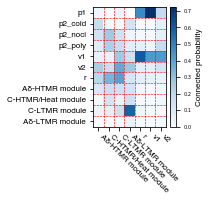

Connected rate matrix


,p1,p2_cold,p2_noci,p2_poly,v1,v2,r,noci_module,np_module,cltmr_module,adltmr_module
noci_module,0.027778,0.166667,0.136842,0.080000,0.049793,0.243119,0.207143,0.104478,0.013793,0.040000,0.000000
np_module,0.000000,0.011765,0.266949,0.239583,0.046481,0.161808,0.339928,0.155462,0.129085,0.063462,0.003906
cltmr_module,0.037975,0.000000,0.140969,0.163743,0.267196,0.376569,0.406312,0.150943,0.047893,0.157795,0.006873
adltmr_module,0.000000,0.125000,0.028571,0.068966,0.147139,0.271540,0.113475,0.132653,0.151316,0.581699,0.049451
r,0.468750,0.000000,0.008584,0.058140,0.598991,0.071831,0.063395,0.019324,0.005941,0.029106,0.003610
v1,0.722513,0.000000,0.006438,0.031830,0.425941,0.073171,0.055901,0.005988,0.003623,0.007561,0.003802
v2,0.183673,0.067669,0.059490,0.167247,0.419895,0.127294,0.047619,0.016327,0.017903,0.004866,0.008734


Number of connected overlapping pairs


,p1,p2_cold,p2_noci,p2_poly,v1,v2,r,noci_module,np_module,cltmr_module,adltmr_module
noci_module,1,5,13,6,12,53,29,7,2,5,0
np_module,0,1,63,46,35,111,189,37,79,33,1
cltmr_module,3,0,32,28,202,270,206,32,25,83,2
adltmr_module,0,1,1,2,54,104,32,13,46,178,9
r,45,0,2,10,475,51,31,4,3,14,1
v1,138,0,3,12,532,78,36,2,2,4,1
v2,27,9,21,48,401,111,21,4,7,2,2


Number of overlapping pairs


,p1,p2_cold,p2_noci,p2_poly,v1,v2,r,noci_module,np_module,cltmr_module,adltmr_module
noci_module,36,30,95,75,241,218,140,67,145,125,48
np_module,79,85,236,192,753,686,556,238,612,520,256
cltmr_module,79,44,227,171,756,717,507,212,522,526,291
adltmr_module,12,8,35,29,367,383,282,98,304,306,182
r,96,62,233,172,793,710,489,207,505,481,277
v1,191,183,466,377,1249,1066,644,334,552,529,263
v2,147,133,353,287,955,872,441,245,391,411,229


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 0) Choose group / cluster orders
# --------------------------------------------------

pre_order = pre_cluster_order if "pre_cluster_order" in globals() else [
    "islet-chtmr",
    "islet-cltmr",
    "islet-adltmr",
    "IN for adhtmr",
]

post_order = post_cluster_order if "post_cluster_order" in globals() else [
    "p1", "p2_cold", "p2_noci", "p2_poly",
    "v1", "v2", "r",
    "noci_module", "np_module", "cltmr_module", "adltmr_module",
]

# --------------------------------------------------
# 1) Bring matrices to presynaptic × postsynaptic
# --------------------------------------------------

A = adjacency_df_completed.copy()
O = overlap_df.copy()

for X in (A, O):
    X.index = X.index.astype(str)
    X.columns = X.columns.astype(str)

pre_ids = set(pre_map.index.astype(str))
post_ids = set(post_map.index.astype(str))

row_in_pre = sum(i in pre_ids for i in A.index)
col_in_post = sum(j in post_ids for j in A.columns)
row_in_post = sum(i in post_ids for i in A.index)
col_in_pre = sum(j in pre_ids for j in A.columns)

if (row_in_post + col_in_pre) > (row_in_pre + col_in_post):
    A = A.T
    O = O.T

O = O.reindex(index=A.index, columns=A.columns)

A = A.apply(pd.to_numeric, errors="coerce")
O = O.apply(pd.to_numeric, errors="coerce")

# --------------------------------------------------
# 2) Build neuron ID lists
# --------------------------------------------------

pre_map_s = pre_map.astype(str)
post_map_s = post_map.astype(str)

ids_by_pre = {
    g: pre_map_s[pre_map_s == g].index.astype(str).intersection(A.index)
    for g in pre_order
}

ids_by_post = {
    c: post_map_s[post_map_s == c].index.astype(str).intersection(A.columns)
    for c in post_order
}

# --------------------------------------------------
# 3) Connected-rate matrix
# connected rate =
# (# overlapping pairs with synapses) /
# (# overlapping pairs)
# --------------------------------------------------

connected_rate_df = pd.DataFrame(
    np.nan,
    index=pre_order,
    columns=post_order,
    dtype=float,
)

n_syn_pairs_df = pd.DataFrame(
    0,
    index=pre_order,
    columns=post_order,
    dtype=int,
)

n_overlap_pairs_df = pd.DataFrame(
    0,
    index=pre_order,
    columns=post_order,
    dtype=int,
)

for pre_type in pre_order:

    rows = list(ids_by_pre[pre_type])

    for post_type in post_order:

        cols = list(ids_by_post[post_type])

        if len(rows) == 0 or len(cols) == 0:
            continue

        blockA = A.loc[rows, cols].to_numpy(dtype=float)
        blockO = O.loc[rows, cols].to_numpy(dtype=float)

        overlap_mask = np.isfinite(blockO) & (blockO > 0)
        syn_mask = np.isfinite(blockA) & (blockA > 0)

        n_overlap = int(np.sum(overlap_mask))
        n_syn_overlap = int(np.sum(overlap_mask & syn_mask))

        n_overlap_pairs_df.loc[pre_type, post_type] = n_overlap
        n_syn_pairs_df.loc[pre_type, post_type] = n_syn_overlap

        if n_overlap > 0:
            connected_rate_df.loc[pre_type, post_type] = (
                n_syn_overlap / n_overlap
            )

# --------------------------------------------------
# 4) Plot
# rows = postsynaptic
# cols = presynaptic
# --------------------------------------------------

SAVE_SVG = True
SVG_PATH = "interneuron_matrix_figure4/connected_rate_overlaponly_070926.svg"

plot_df = connected_rate_df.T.reindex(
    index=post_order,
    columns=pre_order,
)

fig, ax = plt.subplots(figsize=(10, 5))

vmax = (
    np.nanmax(plot_df.to_numpy())
    if np.isfinite(plot_df.to_numpy()).any()
    else 1.0
)

im = ax.imshow(
    plot_df.to_numpy(dtype=float),
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=vmax,
    interpolation="nearest",
)

# Display labels
xlabels = [PRE_LABEL_MAP.get(x, x) for x in pre_order]
ylabels = [POST_LABEL_MAP.get(x, x) for x in post_order]

ax.set_xticks(np.arange(len(pre_order)))
ax.set_xticklabels(
    xlabels,
    rotation=-45,
    ha="left",
    fontsize=8,
    fontname="Helvetica",
)

ax.set_yticks(np.arange(len(post_order)))
ax.set_yticklabels(
    ylabels,
    fontsize=8,
    fontname="Helvetica",
)

# Dashed separators (same style as your other heatmaps)
for x in np.arange(len(pre_order) - 1) + 0.5:
    ax.axvline(x, linestyle="--", color="red", linewidth=0.6)

for y in np.arange(len(post_order) - 1) + 0.5:
    ax.axhline(y, linestyle="--", color="red", linewidth=0.6)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    "Connected probability",
    fontsize=8,
    fontname="Helvetica",
)

cm = 1 / 2.54
fig.set_size_inches(7 * cm, 7 * cm)

plt.tight_layout()

if SAVE_SVG:
    plt.savefig(
        SVG_PATH,
        dpi=600,
        bbox_inches="tight",
    )

plt.show()

# --------------------------------------------------
# 5) Display numeric matrices
# --------------------------------------------------

print("Connected rate matrix")
display(connected_rate_df)

print("Number of connected overlapping pairs")
display(n_syn_pairs_df)

print("Number of overlapping pairs")
display(n_overlap_pairs_df)

# --------------------------------------------------
# 6) Optional save
# --------------------------------------------------

out_dir = "/Users/wangchu/connectivity_analysis/adjacency_overlap_matrix_070826"

# connected_rate_df.to_csv(
#     f"{out_dir}/celltype_connected_rate_overlaponly.csv"
# )

# n_syn_pairs_df.to_csv(
#     f"{out_dir}/celltype_connected_overlap_pairs.csv"
# )

# n_overlap_pairs_df.to_csv(
#     f"{out_dir}/celltype_overlap_pairs.csv"
# )

import numpy as np
import pandas as pd
import matplotlib as mpl

def wiring_specs_from_avg_and_density(
    A_avg_cc: pd.DataFrame,
    D_cc: pd.DataFrame,
    pre_cluster_order,
    post_cluster_order,
    *,
    avg_thresh=0.10,
    dens_thresh=0.0036,
    size_bins=(0.10, 0.25, 0.50, 1.00, np.inf),
    arrow_sizes_pts=(0.5, 1.0, 2.0, 3.0),
    cmap_name="Blues",
    color_cap_percentile=95,
    color_bin_edges=None,   # optional; if provided, use discrete bins for color instead of continuous
):
    """
    Build rule-based wiring specs from:
      - A_avg_cc: avg synapses per all possible pre×post neuron pairs (size driver)
      - D_cc:     density (synapses/μm overlap) computed over overlap>0 pairs only (color driver)

    Returns:
      specs_long:      long-form table for all (pre,post)
      specs_for_wiring:filtered edges that pass avg_thresh & dens_thresh
      plot_mask_wide:  boolean wide matrix indicating plotted edges
      arrow_size_wide: wide matrix of arrow sizes (pts)
      color_hex_wide:  wide matrix of colors (#RRGGBB)
    """
    # --- align ---
    A = A_avg_cc.reindex(index=pre_cluster_order, columns=post_cluster_order).astype(float)
    D = D_cc.reindex(index=pre_cluster_order, columns=post_cluster_order).astype(float)

    # --- long table ---
    specs_long = (
        pd.DataFrame({
            "pre": np.repeat(list(pre_cluster_order), len(post_cluster_order)),
            "post": list(post_cluster_order) * len(pre_cluster_order),
            "A_avg": A.to_numpy().ravel(),
            "dens":  D.to_numpy().ravel(),
        })
    )

    # --- pass mask ---
    pass_mask = (
        np.isfinite(specs_long["A_avg"].to_numpy()) &
        np.isfinite(specs_long["dens"].to_numpy()) &
        (specs_long["A_avg"].to_numpy() >= float(avg_thresh)) &
        (specs_long["dens"].to_numpy()  >= float(dens_thresh))
    )
    specs_for_wiring = specs_long.loc[pass_mask].copy()

    # --- arrow size binning (based on A_avg) ---
    bins = np.array(size_bins, dtype=float)
    if len(arrow_sizes_pts) != (len(bins) - 1):
        raise ValueError("arrow_sizes_pts must have length len(size_bins)-1")

    # pd.cut returns category indices 0..n-1
    size_idx = pd.cut(
        specs_long["A_avg"],
        bins=[-np.inf] + list(bins),  # so values < first threshold become bin -1 (we’ll handle)
        labels=False
    )
    # size_idx: 0 corresponds to (-inf, size_bins[0]]; we want:
    #   <= size_bins[0] -> 0 (smallest) etc. but we will only plot pass edges anyway.
    # convert to 0..n-1 within arrow_sizes
    # bins we gave: [-inf, 0.1, 0.25, 0.5, 1.0, inf] => indices 0..4
    # arrow_sizes_pts length should be 5 in that case.
    size_pts = np.full(len(specs_long), np.nan, dtype=float)
    if size_idx is not None:
        size_idx = size_idx.to_numpy()
        ok = np.isfinite(size_idx)
        size_idx_int = size_idx[ok].astype(int)
        # clamp just in case
        size_idx_int = np.clip(size_idx_int, 0, len(arrow_sizes_pts) - 1)
        size_pts[ok] = np.array(arrow_sizes_pts, dtype=float)[size_idx_int]

    # --- color mapping (based on dens) ---
    dens_vals = specs_long["dens"].to_numpy(dtype=float)
    finite_d = dens_vals[np.isfinite(dens_vals)]
    if finite_d.size == 0:
        vmin, vmax = 0.0, 1.0
    else:
        vmin = float(np.nanmin(finite_d))
        vmax = float(np.nanpercentile(finite_d, color_cap_percentile)) if color_cap_percentile is not None else float(np.nanmax(finite_d))
        if vmax <= vmin:
            vmax = vmin + 1e-9

    cmap = mpl.cm.get_cmap(cmap_name)

    if color_bin_edges is None:
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        rgba = np.full((len(dens_vals), 4), np.nan, dtype=float)
        m = np.isfinite(dens_vals)
        rgba[m] = cmap(norm(dens_vals[m]))
    else:
        # discrete bins: dens < edge0 -> lightest; > last -> darkest
        edges = np.array(color_bin_edges, dtype=float)
        # create bin indices 0..len(edges) (len(edges)+1 bins)
        bin_idx = np.digitize(dens_vals, edges, right=False)
        # map bin_idx to evenly spaced colors across cmap
        # (0 -> low end, max -> high end)
        max_bin = max(int(np.nanmax(bin_idx[np.isfinite(bin_idx)])), 1) if np.any(np.isfinite(bin_idx)) else 1
        rgba = np.full((len(dens_vals), 4), np.nan, dtype=float)
        m = np.isfinite(dens_vals)
        rgba[m] = cmap(bin_idx[m] / float(max_bin))

    def rgba_to_hex(rgba_row):
        if not np.isfinite(rgba_row).all():
            return np.nan
        r, g, b, a = rgba_row
        return mpl.colors.to_hex((r, g, b), keep_alpha=False)

    color_hex = np.array([rgba_to_hex(r) for r in rgba], dtype=object)

    # --- wide outputs ---
    plot_mask_wide = pd.DataFrame(False, index=pre_cluster_order, columns=post_cluster_order)
    arrow_size_wide = pd.DataFrame(np.nan, index=pre_cluster_order, columns=post_cluster_order, dtype=float)
    color_hex_wide  = pd.DataFrame(np.nan, index=pre_cluster_order, columns=post_cluster_order, dtype=object)

    # fill wide from long
    for (pre, post, aavg, dens, sp, hx, keep) in zip(
        specs_long["pre"], specs_long["post"],
        specs_long["A_avg"], specs_long["dens"],
        size_pts, color_hex, pass_mask
    ):
        if keep:
            plot_mask_wide.loc[pre, post] = True
            arrow_size_wide.loc[pre, post] = sp
            color_hex_wide.loc[pre, post]  = hx

    # also add convenience columns to filtered table
    specs_for_wiring["arrow_size_pts"] = [
        arrow_size_wide.loc[r.pre, r.post] for r in specs_for_wiring.itertuples(index=False)
    ]
    specs_for_wiring["color_hex"] = [
        color_hex_wide.loc[r.pre, r.post] for r in specs_for_wiring.itertuples(index=False)
    ]

    return specs_long, specs_for_wiring, plot_mask_wide, arrow_size_wide, color_hex_wide


# when plot the wiring diagram, the density only consider overlap pairs

import numpy as np
import pandas as pd

def _orient_pres_post(M: pd.DataFrame, pre_map: pd.Series, post_map: pd.Series) -> pd.DataFrame:
    """Ensure M is pres×post (rows=pre IDs, cols=post IDs). Auto-transpose if needed."""
    M = M.copy()
    M.index = M.index.astype(str); M.columns = M.columns.astype(str)
    pre_ids  = set(pre_map.index.astype(str))
    post_ids = set(post_map.index.astype(str))
    row_in_pre  = sum(i in pre_ids  for i in M.index)
    col_in_post = sum(j in post_ids for j in M.columns)
    row_in_post = sum(i in post_ids for i in M.index)
    col_in_pre  = sum(j in pre_ids  for j in M.columns)
    if (row_in_post + col_in_pre) > (row_in_pre + col_in_post):
        M = M.T
    return M

def compute_overlaponly_density_grouped(
    adjacency_df_completed: pd.DataFrame,  # per-pair synapse counts
    overlap_df: pd.DataFrame,              # per-pair overlap (μm)
    pre_map: pd.Series,                    # pre_id -> pre_cluster
    post_map: pd.Series,                   # post_id -> post_cluster
    pre_cluster_order,                     # list of pre clusters
    post_cluster_order                     # list of post clusters
) -> pd.DataFrame:
    """
    Returns D_cc_overlaponly: each tile is mean( synapses/overlap ) over pairs with overlap>0.
    Non-overlap pairs do NOT contribute (treated as NaN).
    """
    A = _orient_pres_post(adjacency_df_completed, pre_map, post_map).apply(pd.to_numeric, errors="coerce")
    O = _orient_pres_post(overlap_df,               pre_map, post_map).reindex(index=A.index, columns=A.columns)
    O = O.apply(pd.to_numeric, errors="coerce")

    pre_map_s  = pre_map.astype(str)
    post_map_s = post_map.astype(str)

    # build ID lists per tile
    ids_by_pre  = {g: pre_map_s[pre_map_s == g].index.astype(str).intersection(A.index) for g in pre_cluster_order}
    ids_by_post = {c: post_map_s[post_map_s == c].index.astype(str).intersection(A.columns) for c in post_cluster_order}

    D_cc = pd.DataFrame(np.nan, index=pre_cluster_order, columns=post_cluster_order, dtype=float)

    for g in pre_cluster_order:
        rows = list(ids_by_pre[g])
        for c in post_cluster_order:
            cols = list(ids_by_post[c])
            if not rows or not cols:
                continue
            blockA = A.loc[rows, cols].to_numpy(dtype=float)
            blockO = O.loc[rows, cols].to_numpy(dtype=float)

            with np.errstate(divide='ignore', invalid='ignore'):
                dens = np.divide(blockA, blockO, where=(blockO > 0))
            # keep only overlap pairs; others -> NaN
            dens = np.where((blockO > 0) & np.isfinite(dens), dens, np.nan)

            D_cc.loc[g, c] = np.nanmean(dens) if np.isfinite(dens).any() else np.nan

    return D_cc

# ---------- Build overlap-only density and run your wiring spec ----------
D_cc_overlaponly = compute_overlaponly_density_grouped(
    adjacency_df_completed=adjacency_df_completed,
    overlap_df=overlap_df,
    pre_map=pre_map,
    post_map=post_map,
    pre_cluster_order=pre_cluster_order,
    post_cluster_order=post_cluster_order,
)

# Now feed the overlap-only density into your rule-based wiring spec
specs_long, specs_for_wiring, plot_mask_wide, arrow_size_wide, color_hex_wide = wiring_specs_from_avg_and_density(
    A_avg_cc,                     # your avg synapse count matrix (whatever definition you chose)
    D_cc_overlaponly,             # <-- density averaged only over overlap pairs
    pre_cluster_order,
    post_cluster_order,
    avg_thresh=0.10,
    dens_thresh=0.0036,
    size_bins=(0.10, 0.25, 0.50, 1.00, np.inf),
    arrow_sizes_pts=(0.5, 1, 2, 3),
    cmap_name="Blues",
    color_cap_percentile=95,
    color_bin_edges=(0.0036, 0.007, 0.014),
)

# See only the connections that pass
display(specs_for_wiring)


import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# tiny typography
mpl.rcParams.update({
    "font.size": 5, "axes.titlesize": 5, "axes.labelsize": 5,
    "xtick.labelsize": 5, "ytick.labelsize": 5, "legend.fontsize": 5,
})

def plot_A_avg_hist(A_avg_cc, bins="fd", include_zeros=False, fig_cm=(6,4),
                    savepath=None, save_svg_path=None, title=None):
    """
    Plot histogram of average synapses per pre–post pair from A_avg_cc.

    Parameters
    ----------
    A_avg_cc : pd.DataFrame (pre x post)
    bins     : int or sequence or {'auto','fd','doane','scott',...}
               default 'fd' (Freedman–Diaconis)
    include_zeros : include zeros in the histogram (default False)
    fig_cm   : figure size in centimeters (width, height)
    savepath : optional PNG path
    save_svg_path : optional SVG path
    title    : optional title
    """
    vals = A_avg_cc.to_numpy().ravel()
    vals = vals[np.isfinite(vals)]
    if not include_zeros:
        vals = vals[vals > 0]

    fig, ax = plt.subplots(figsize=(fig_cm[0]/2.54, fig_cm[1]/2.54), dpi=300)
    ax.hist(vals, bins=bins, color="0.2")
    ax.set_xlabel("Average synapses per pre–post pair")
    ax.set_ylabel("Count (cluster pairs)")
    ax.set_title(title or "Distribution of A_avg_cc")
    ax.grid(True, linestyle=":", linewidth=0.3, alpha=0.5)
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=300)
    if save_svg_path:
        plt.savefig(save_svg_path, dpi=300)
    plt.show()

# Example usage:
plot_A_avg_hist(A_avg_cc, bins="fd", include_zeros=False, fig_cm=(6,4))
#plot_A_avg_hist(A_avg_cc, bins=np.arange(0, 3.05, 0.05), save_svg_path="A_avg_hist.svg")


import numpy as np
import matplotlib.pyplot as plt

# Flatten to 1D and drop NaNs
vals = np.asarray(D_cc.values).ravel()
vals = vals[np.isfinite(vals)]

plt.figure(figsize=(6/2.54, 4/2.54), dpi=300)  # ~6×4 cm
plt.hist(vals, bins="fd", color="0.2")         # use an automatic rule; or pass an int/array for bins
plt.xlabel("density_cc")
plt.ylabel("count")
plt.title("Distribution of density_cc")
plt.grid(True, linestyle=":", linewidth=0.3, alpha=0.5)
plt.tight_layout()
plt.show()


# rules about how to plot the wiring diagram, threshold for size is 0.1 and threshold for density is 0.0025. 
#Just add one more size bin, 0.1 -0.25 size 0.5, 0.25 -0.5 size 1, 0.5 -1 size 2 and above 1 size 3
#also density from 0.0025 to 0.005 go with 0.0025 color, 0.005 - 0.01 with 0.05 color, above 0.01 with 0.01 color.


import numpy as np
import pandas as pd
import matplotlib as mpl

def wiring_specs_from_avg_and_density(
    A_avg_cc: pd.DataFrame,
    D_cc: pd.DataFrame,
    pre_cluster_order,
    post_cluster_order,
    *,
    # ---- AND thresholds ----
    avg_thresh=0.10,                 # require A_avg_cc ≥ 0.1
    dens_thresh=0.0025,              # require D_cc     ≥ 0.0025
    # ---- arrow size from A_avg_cc bins (FOUR bins now) ----
    # [0.10,0.25)→0.5 pt, [0.25,0.50)→1 pt, [0.50,1.00)→2 pt, [1.00,∞)→3 pt
    size_bins=(0.10, 0.25, 0.50, 1.00, np.inf),
    arrow_sizes_pts=(0.5, 1, 2, 3),
    # ---- colormap + cap ----
    cmap_name="Blues",
    color_cap_percentile=95,
    # ---- density→color bin anchors ----
    # [0.0025,0.005) -> color at 0.0025
    # [0.005,0.01)   -> color at 0.005
    # [0.01,  +inf)  -> color at 0.01
    color_bin_edges=(0.0025, 0.005, 0.01)
):
    """
    Build cluster→cluster wiring specs with AND rule, 4-bin arrow sizes, and binned hex colors.

    Returns
    -------
    specs_long        : tidy table per (pre, post)
    plot_mask_wide    : DataFrame[bool] (draw if True)
    arrow_size_wide   : DataFrame[float] (0 / 0.5 / 1 / 2 / 3 pt)
    color_hex_wide    : DataFrame[str or None], e.g. '#2b6cb0'
    """
    # Reorder
    A = A_avg_cc.reindex(index=pre_cluster_order, columns=post_cluster_order)
    D = D_cc.reindex(index=pre_cluster_order, columns=post_cluster_order)

    avg  = A.to_numpy(float)
    dens = D.to_numpy(float)
    m, n = avg.shape
    finite = np.isfinite(avg) & np.isfinite(dens)

    # ---- AND rule ----
    plot_mask = finite & (avg >= float(avg_thresh)) & (dens >= float(dens_thresh))

    # ---- arrow sizes from A_avg_cc (4 bins) ----
    if len(arrow_sizes_pts) != (len(size_bins) - 1):
        raise ValueError("arrow_sizes_pts must have length len(size_bins)-1")
    sizes = np.zeros_like(avg, dtype=float)
    # [0.10,0.25) -> 0.5
    sizes[(avg >= size_bins[0]) & (avg < size_bins[1])] = arrow_sizes_pts[0]
    # [0.25,0.50) -> 1
    sizes[(avg >= size_bins[1]) & (avg < size_bins[2])] = arrow_sizes_pts[1]
    # [0.50,1.00) -> 2
    sizes[(avg >= size_bins[2]) & (avg < size_bins[3])] = arrow_sizes_pts[2]
    # [1.00,∞)    -> 3
    sizes[(avg >= size_bins[3])]                         = arrow_sizes_pts[3]
    sizes[~plot_mask] = 0.0

    # ---- color normalization with percentile cap ----
    dens_finite_all = dens[np.isfinite(dens)]
    if dens_finite_all.size == 0:
        vmin, vmax = 0.0, 1.0
    else:
        vmin = float(np.nanmin(dens_finite_all))
        vmax = float(np.nanpercentile(dens_finite_all, color_cap_percentile))
        if vmax <= vmin:
            vmax = vmin + 1e-12

    cmap = mpl.cm.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # ---- binned density colors → hex ----
    b1, b2, b3 = color_bin_edges  # 0.0025, 0.005, 0.01
    color_hex = np.empty(avg.shape, dtype=object)
    for i in range(m):
        for j in range(n):
            if not plot_mask[i, j]:
                color_hex[i, j] = None
                continue
            d = dens[i, j]
            if   (d >= b1) and (d < b2): anchor = b1
            elif (d >= b2) and (d < b3): anchor = b2
            else:                        anchor = b3
            rgba = cmap(norm(float(np.clip(anchor, vmin, vmax))))
            color_hex[i, j] = mpl.colors.to_hex(rgba, keep_alpha=False)

    # ---- package results ----
    plot_mask_wide  = pd.DataFrame(plot_mask,  index=A.index, columns=A.columns)
    arrow_size_wide = pd.DataFrame(sizes,      index=A.index, columns=A.columns)
    color_hex_wide  = pd.DataFrame(color_hex,  index=A.index, columns=A.columns)

    specs_long = (
        pd.DataFrame({
            "pre_cluster":  np.repeat(A.index.values, n),
            "post_cluster": np.tile(A.columns.values, m),
            "avg_cc":       avg.ravel(),
            "density":      dens.ravel(),
            "plot":         plot_mask.ravel(),
            "arrow_pt":     sizes.ravel(),
            "color_hex":    color_hex.ravel(),
        })
        .assign(
            density_capped=lambda df: np.minimum(df["density"].values, vmax),
            color_vmin=vmin,
            color_vmax=vmax,
            avg_thresh=avg_thresh,
            dens_thresh=dens_thresh
        )
    )

    return specs_long, plot_mask_wide, arrow_size_wide, color_hex_wide


# ===================== Example call =====================
specs_long, plot_mask_wide, arrow_size_wide, color_hex_wide = wiring_specs_from_avg_and_density(
    A_avg_cc, D_cc,
    pre_cluster_order, post_cluster_order,
    avg_thresh=0.10,
    dens_thresh=0.0025,
    size_bins=(0.10, 0.25, 0.50, 1.00, np.inf),  # 4 bins
    arrow_sizes_pts=(0.5, 1, 2, 3),
    cmap_name="Blues",
    color_cap_percentile=95,
    color_bin_edges=(0.0025, 0.005, 0.01)
)

# display(plot_mask_wide); display(arrow_size_wide); display(color_hex_wide)
display(specs_long.query("plot").sort_values(['pre_cluster','post_cluster']))
